# Var

In [23]:
work_dir <- "/ebio/abt3_projects2/microc_metagenomics/out/MicroC_binning"
samples <- c("MC1")

In [24]:
library(dplyr)
library(ggplot2)
library(LeyLabRMisc)
library(data.table)
library(tidyverse)
library(pROC)
library(PRROC)
library(ComplexHeatmap)
library(circlize)
library(Biostrings)
library(scales)

In [96]:
# limit the size of output tables
df.dims(30)

# Load

## Contacts

In [26]:
# Load list with all the contacts between contigs (normalized intensities)
all_contacts <- fread(file.path(work_dir, "MC1_long_plasmids/norm/Normalized_all_contacts_list.tsv"), sep = "\t")
#all_contacts <- fread(file.path(work_dir, "MC1_long_plasmids/norm/Normalized_contacts_filtered_list.tsv"), sep = "\t")
colnames(all_contacts) <- c("index1","index2","contacts")
all_contacts

index1,index2,contacts
<chr>,<chr>,<dbl>
contig_1,contig_1000,355.456
contig_1,contig_10000,0.000
contig_1,contig_10002,0.000
contig_1,contig_10003,0.000
contig_1,contig_10005,0.000
⋮,⋮,⋮
contig_circular_4,contig_circular_7,0
contig_circular_4,contig_circular_8,0
contig_circular_6,contig_circular_7,0


## Contig-bin association

In [27]:
# Load asociation of contigs to bins
bins <- fread(file.path(work_dir, "MC1_long_plasmids/DAS_Tool/bins_DASTool_contig2bin.tsv"), sep = "\t", header = F)

# Add a 'sample' column by extracting the part before the '__'
#bins$sample <- str_extract(bins$V1, "^[^_]+")

# Remove the 'X__' part from the first column
bins$V1 <- str_replace(bins$V1, "^[^_]+__", "")

# Rename the columns
colnames(bins) <- c('contig', 'bin')#, 'sample')
bins

contig,bin
<chr>,<chr>
contig_13093,MetaCC_bin_0200
contig_13094,MetaCC_bin_0200
contig_1997,MetaCC_bin_0200
contig_2436,MetaCC_bin_0200
contig_2884,MetaCC_bin_0200
⋮,⋮
contig_8198,ImputeCC_bin_0128
contig_8206,ImputeCC_bin_0128
contig_8563,ImputeCC_bin_0128


## Bins quality

In [28]:
# Load quality of bns
bins_quality <- fread("/ebio/abt3_projects2/long_reads_workflow/out/llg/MC1_with_microc/checkm2/quality_report.tsv", sep = "\t", header = T)
bins_quality

Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Additional_Notes
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>
ImputeCC_bin_0011,99.99,1.08,Neural Network (Specific Model),11,0.886,400703,313.5842,3435960,0.42,3244,None
ImputeCC_bin_0012,97.23,1.80,Gradient Boost (General Model),11,0.864,386709,320.4316,2530848,0.52,2280,None
ImputeCC_bin_0013,98.06,1.38,Neural Network (Specific Model),11,0.883,317249,340.9270,3118299,0.54,2697,None
ImputeCC_bin_0018,97.53,4.41,Gradient Boost (General Model),11,0.832,891012,307.9797,1748267,0.30,1577,None
ImputeCC_bin_0022_sub,99.96,1.90,Neural Network (Specific Model),11,0.874,330668,353.1501,2241510,0.56,1852,None
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_88_sub,96.85,26.02,Gradient Boost (General Model),11,0.825,102956,275.9102,4440023,0.29,4433,None
semibin2_bin_94,94.46,0.32,Gradient Boost (General Model),11,0.855,547702,303.8003,2253510,0.57,2118,None
semibin2_bin_95_sub,99.96,11.15,Neural Network (Specific Model),11,0.827,185651,317.9054,3271128,0.55,2843,None


## Taxa

In [29]:
# Import the taxonomic classification of the bins from GTDBTK
tax_levs <- c('Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species')
tax = fread("/ebio/abt3_projects2/long_reads_workflow/out/llg/MC1_with_microc/gtdbtk/gtdbtk_summary_wTaxid.tsv") %>%
  select(-starts_with('other_'), -note) %>%
  mutate(classification = gsub('^d__', '', classification),
         classification = gsub(';[pcofgs]__', ';', classification)) %>%
  separate(classification, tax_levs, sep = ';') %>%
  mutate(across(all_of(tax_levs), ~ifelse((. == '' | is.na(.)), 'unclassified', .)))
tax$sample <- "MC1"
tax

user_genome,Domain,Phylum,Class,Order,Family,Genus,Species,fastani_reference,fastani_reference_radius,⋯,closest_placement_af,pplacer_taxonomy,classification_method,msa_percent,translation_table,red_value,warnings,taxid,taxid_rank,sample
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<chr>,<int64>,<chr>,<chr>
ImputeCC_bin_0011,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Mediterraneibacter,Mediterraneibacter torques,GCF_000153925.1,95.0,⋯,0.89,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Mediterraneibacter;s__,taxonomic classification defined by topology and ANI,95.75,11,N/A,N/A,3907049719,species,MC1
ImputeCC_bin_0012,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,CAG-272,UMGS1312,UMGS1312 sp900550625,GCA_900550625.1,95.0,⋯,0.96,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__CAG-272;g__UMGS1312;s__,taxonomic classification defined by topology and ANI,95.85,11,N/A,N/A,3803871039,species,MC1
ImputeCC_bin_0013,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Rikenellaceae,Alistipes_A,Alistipes_A pullistercoris,GCF_009557455.1,95.0,⋯,0.93,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Rikenellaceae;g__Alistipes_A;s__,taxonomic classification defined by topology and ANI,94.34,11,N/A,N/A,626865341,species,MC1
ImputeCC_bin_0018,Bacteria,Firmicutes_A,Clostridia,TANB77,CAG-508,CAG-273,unclassified,N/A,N/A,⋯,0.54,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__TANB77;f__CAG-508;g__CAG-273;s__,taxonomic classification defined by topology and ANI,87.09,11,0.9622193349250187,Genome not assigned to closest species as it falls outside its pre-defined ANI radius,603574435,genus,MC1
ImputeCC_bin_0022_sub,Bacteria,Actinobacteriota,Actinomycetia,Actinomycetales,Bifidobacteriaceae,Bifidobacterium,Bifidobacterium catenulatum,GCF_001025195.1,96.3948,⋯,0.9,d__Bacteria;p__Actinobacteriota;c__Actinomycetia;o__Actinomycetales;f__Bifidobacteriaceae;g__Bifidobacterium;s__,taxonomic classification defined by topology and ANI,92.95,11,N/A,N/A,1546125656,species,MC1
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_88_sub,Bacteria,Firmicutes_A,Clostridia,Peptostreptococcales,Peptostreptococcaceae,Intestinibacter,Intestinibacter bartlettii,GCF_000154445.1,95.0,⋯,0.92,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Peptostreptococcales;f__Peptostreptococcaceae;g__Intestinibacter;s__,taxonomic classification defined by topology and ANI,86.74,11,N/A,Genome has more than 10.8% of markers with multiple hits,1590332758,species,MC1
semibin2_bin_94,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Butyricicoccaceae,Agathobaculum,Agathobaculum sp003481705,GCF_003481705.1,95.0,⋯,0.82,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Butyricicoccaceae;g__Agathobaculum;s__,taxonomic classification defined by topology and ANI,84.00,11,N/A,N/A,4200889498,species,MC1
semibin2_bin_95_sub,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Ruminococcaceae,Gemmiger,Gemmiger qucibialis,GCF_003324125.1,95.0,⋯,0.71,d__Bacteria;p__Firmicutes_A;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Gemmiger;s__,taxonomic classification defined by topology and ANI,92.30,11,N/A,N/A,3446184927,species,MC1


## Plasmids

In [30]:
# Read the fasta file of linear plasmid contigs
fasta_linear <- readDNAStringSet("/ebio/abt3_projects2/hic_metagenomics_pilot/mbermejo/out/llp/MC1/linear/predicted_plasmids/all_plasmid_contigs.fa")

# Extract names and store in a data frame
plasmid_linear <- data.frame(
  Contig = names(fasta_linear),
  Prediction = "plasmid_linear",
  Length = width(fasta_linear)
)

# Extract Sample from plasid (before first "_")
plasmid_linear$Sample <- sub("_.*", "", plasmid_linear$Contig)

plasmid_linear$Contig <- sub(".*(contig_\\d+)", "\\1", plasmid_linear$Contig)

plasmid_linear

Contig,Prediction,Length,Sample
<chr>,<chr>,<int>,<chr>
contig_1000,plasmid_linear,299155,MC1
contig_1001,plasmid_linear,27321,MC1
contig_10021,plasmid_linear,8850,MC1
contig_10022,plasmid_linear,8947,MC1
contig_10045,plasmid_linear,8270,MC1
⋮,⋮,⋮,⋮
contig_9950,plasmid_linear,23542,MC1
contig_9951,plasmid_linear,26977,MC1
contig_997,plasmid_linear,89454,MC1


In [31]:
# Read the fasta file of circular plasmid contigs
fasta_circular <- readDNAStringSet("/ebio/abt3_projects2/hic_metagenomics_pilot/mbermejo/out/llp/MC1/circular/viralverify/circular_plasmid.fasta")

# Extract names and store in a data frame
plasmid_circular <- data.frame(
  Contig = names(fasta_circular),
  Prediction = "plasmid_circular",
  Length = width(fasta_circular)
)

# Extract Sample from plasid (before first "_")
plasmid_circular$Sample <- sub("_.*", "", plasmid_circular$Contig)

plasmid_circular$Contig <- sub(".*(contig_.*)", "\\1", plasmid_circular$Contig)
plasmid_circular$Contig <- str_trim(plasmid_circular$Contig)
plasmid_circular

Contig,Prediction,Length,Sample
<chr>,<chr>,<int>,<chr>
contig_circular_0,plasmid_circular,7552,MC1
contig_circular_1,plasmid_circular,5576,MC1
contig_circular_2,plasmid_circular,5424,MC1
contig_circular_3,plasmid_circular,2830,MC1
contig_circular_4,plasmid_circular,12639,MC1
contig_circular_5,plasmid_circular,16183,MC1
contig_circular_6,plasmid_circular,6398,MC1
contig_circular_7,plasmid_circular,5331,MC1
contig_circular_8,plasmid_circular,4203,MC1


# Data processing

## Contacts

In [32]:
# Get all the plasmid sequences in the same table
plasmids <- rbind(plasmid_linear, plasmid_circular) %>%
    filter(Length > 1000) %>% filter(Length < 200000)
plasmids

Contig,Prediction,Length,Sample
<chr>,<chr>,<int>,<chr>
contig_1001,plasmid_linear,27321,MC1
contig_10021,plasmid_linear,8850,MC1
contig_10022,plasmid_linear,8947,MC1
contig_10045,plasmid_linear,8270,MC1
contig_1006,plasmid_linear,51904,MC1
⋮,⋮,⋮,⋮
contig_circular_4,plasmid_circular,12639,MC1
contig_circular_5,plasmid_circular,16183,MC1
contig_circular_6,plasmid_circular,6398,MC1


In [33]:
# Filter the contacts to exclude the ones that involve circular plasmids
contacts <- list()
for (i in samples){
  #contacts[[i]] <- all_contacts[all_contacts$sample == i, ]
  plasmid_circular_filtered <- plasmid_circular[plasmid_circular$Sample == i,]
  contacts[[i]] <- all_contacts %>%
    filter(!(index1 %in% plasmid_circular_filtered$Contig | index2 %in% plasmid_circular_filtered$Contig)) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% plasmid_circular_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% plasmid_circular_filtered$Contig, TRUE, FALSE)
  )
}
contacts
joined_contacts <- rbind(contacts[[1]])#, contacts[[2]], contacts[[3]], contacts[[4]])

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_1000,355.456,FALSE,FALSE
contig_1,contig_10000,0.000,FALSE,FALSE
contig_1,contig_10002,0.000,FALSE,FALSE
contig_1,contig_10003,0.000,FALSE,FALSE
contig_1,contig_10005,0.000,FALSE,FALSE
⋮,⋮,⋮,⋮,⋮
contig_9995,contig_9997,276.244,FALSE,FALSE
contig_9995,contig_9999,0.000,FALSE,FALSE
contig_9996,contig_9997,98390.546,FALSE,FALSE


In [34]:
# Symmetrize contact table
contact_sym <- joined_contacts %>%
  dplyr::rename(x = index1, y = index2) %>%
  bind_rows(joined_contacts %>% dplyr::rename(x = index2, y = index1))
contact_sym

x,y,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_1000,355.456,FALSE,FALSE
contig_1,contig_10000,0.000,FALSE,FALSE
contig_1,contig_10002,0.000,FALSE,FALSE
contig_1,contig_10003,0.000,FALSE,FALSE
contig_1,contig_10005,0.000,FALSE,FALSE
⋮,⋮,⋮,⋮,⋮
contig_9997,contig_9995,276.244,FALSE,FALSE
contig_9999,contig_9995,0.000,FALSE,FALSE
contig_9997,contig_9996,98390.546,FALSE,FALSE


In [35]:
# Add bin information
contacts_bins <- contact_sym %>%
  left_join(bins, by = c("x" = "contig")) %>%
  dplyr::rename(binx = bin) %>%
  left_join(bins, by = c("y" = "contig")) %>%
  dplyr::rename(biny = bin) %>%
  filter(!is.na(binx), !is.na(biny))
contacts_bins

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10005,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0105
contig_1,contig_10006,410.804,FALSE,FALSE,semibin2_bin_61_sub,semibin2_bin_120
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9997,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77


In [36]:
# Create heatmaps and orders per sample
#samples <- unique(bins$sample)
heatmaps <- list()
orders <- list()

for (s in samples) {
  orders[[s]] <- bins %>%
    #filter(sample == s) %>%
    arrange(bin, contig) %>%
    pull(contig)

  heatmaps[[s]] <- contacts_bins %>%
    #filter(sample == s) %>%
    mutate(
      x = factor(x, levels = orders[[s]]),
      y = factor(y, levels = orders[[s]])
    )
}

heatmaps
orders

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<fct>,<fct>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10005,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0105
contig_1,contig_10006,410.804,FALSE,FALSE,semibin2_bin_61_sub,semibin2_bin_120
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9997,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77


$MC1
   [1] "contig_10861"      "contig_11479"      "contig_1240"      
   [4] "contig_1254"       "contig_13259"      "contig_13293"     
   [7] "contig_13655"      "contig_1786"       "contig_1866"      
  [10] "contig_2035"       "contig_2186"       "contig_2491"      
  [13] "contig_3070"       "contig_3288"       "contig_3536"      
  [16] "contig_4181"       "contig_5710"       "contig_5713"      
  [19] "contig_5714"       "contig_5715"       "contig_5716"      
  [22] "contig_6110"       "contig_6641"       "contig_6752"      
  [25] "contig_924"        "contig_10424"      "contig_1089"      
  [28] "contig_13002"      "contig_1714"       "contig_2515"      
  [31] "contig_2517"       "contig_2518"       "contig_2519"      
  [34] "contig_3575"       "contig_4886"       "contig_10297"     
  [37] "contig_10493"      "contig_13305"      "contig_14068"     
  [40] "contig_3170"       "contig_3995"       "contig_4002"      
  [43] "contig_4803"       "contig_5403"       "contig_6827"      
  [46] "contig_9962"       "contig_11096"      "contig_2246"      
  [49] "contig_10470"      "contig_12035"      "contig_12043"     
  [52] "contig_12585"      "contig_12586"      "contig_12587"     
  [55] "contig_13860"      "contig_14026"      "contig_6888"      
  [58] "contig_7911"       "contig_8467"       "contig_8507"      
  [61] "contig_8508"       "contig_9789"       "contig_9791"      
  [64] "contig_9792"       "contig_9996"       "contig_9997"      
  [67] "contig_10035"      "contig_10141"      "contig_12564"     
  [70] "contig_13298"      "contig_13358"      "contig_1936"      
  [73] "contig_5649"       "contig_5650"       "contig_6735"      
  [76] "contig_6738"       "contig_1099"       "contig_1110"      
  [79] "contig_1134"       "contig_1135"       "contig_12913"     
  [82] "contig_13263"      "contig_13391"      "contig_1862"      
  [85] "contig_2414"       "contig_2415"       "contig_3124"      
  [88] "contig_3386"       "contig_3546"       "contig_4027"      
  [91] "contig_4366"       "contig_4592"       "contig_4596"      
  [94] "contig_4599"       "contig_4600"       "contig_4686"      
  [97] "contig_542"        "contig_781"        "contig_10232"     
 [100] "contig_11159"      "contig_11283"      "contig_13217"     
 [103] "contig_13274"      "contig_13496"      "contig_13500"     
 [106] "contig_13504"      "contig_2725"       "contig_2839"      
 [109] "contig_2845"       "contig_2941"       "contig_3246"      
 [112] "contig_4080"       "contig_5196"       "contig_5528"      
 [115] "contig_5636"       "contig_6018"       "contig_6556"      
 [118] "contig_7781"       "contig_10638"      "contig_12652"     
 [121] "contig_1344"       "contig_14182"      "contig_1477"      
 [124] "contig_4898"       "contig_5216"       "contig_7977"      
 [127] "contig_12118"      "contig_2014"       "contig_616"       
 [130] "contig_847"        "contig_848"        "contig_937"       
 [133] "contig_982"        "contig_12989"      "contig_1356"      
 [136] "contig_1458"       "contig_2917"       "contig_2926"      
 [139] "contig_5878"       "contig_6007"       "contig_6533"      
 [142] "contig_6536"       "contig_6593"       "contig_8203"      
 [145] "contig_884"        "contig_948"        "contig_953"       
 [148] "contig_1255"       "contig_13127"      "contig_1742"      
 [151] "contig_352"        "contig_3542"       "contig_3635"      
 [154] "contig_806"        "contig_918"        "contig_1017"      
 [157] "contig_1151"       "contig_13034"      "contig_13758"     
 [160] "contig_1408"       "contig_1442"       "contig_1450"      
 [163] "contig_1451"       "contig_2037"       "contig_3016"      
 [166] "contig_3072"       "contig_3603"       "contig_4087"      
 [169] "contig_423"        "contig_4263"       "contig_4375"      
 [172] "contig_455"        "contig_467"        "contig_557"       
 [175] "contig_6225"       "contig_6747"       "contig_888"       
 [178] "contig_967"        "contig_10685" 

In [37]:
# Function to generate heatmap matrix
make_heatmap_matrix <- function(df, contig_order) {
  df %>%
    mutate(x = as.character(x), y = as.character(y)) %>%
    select(x, y, contacts) %>%
    pivot_wider(names_from = x, values_from = contacts, values_fill = 0) %>%
    column_to_rownames("y") %>%
    as.matrix() %>%
    { .[contig_order[contig_order %in% rownames(.)], contig_order[contig_order %in% colnames(.)]] }
}

get_min_nonzero <- function(mat) {
  min(mat[mat > 0])
}

In [38]:
# Get the contig and bin association into the table with all the contacts
# Merge all_contacts with bins to get bin1
joined_contacts <- merge(joined_contacts, bins, by.x = c("index1"), by.y = c("contig"), all.x = TRUE)
setnames(joined_contacts, "bin", "bin1")
# Merge all_contacts with bins to get bin2
joined_contacts <- merge(joined_contacts, bins, by.x = c("index2"), by.y = c("contig"), all.x = TRUE)
setnames(joined_contacts, "bin", "bin2")
# Reorder columns to desired order
joined_contacts <- joined_contacts[, .(index1, index2, contacts, bin1, bin2)]
joined_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10000,0.000,semibin2_bin_61_sub,NA
contig_1000,contig_10000,0.000,MetaCC_bin_0170,NA
contig_1,contig_10002,0.000,semibin2_bin_61_sub,NA
contig_1000,contig_10002,0.000,MetaCC_bin_0170,NA
⋮,⋮,⋮,⋮,⋮
contig_9993,contig_9999,0,ImputeCC_bin_0111,NA
contig_9994,contig_9999,0,semibin2_bin_77,NA
contig_9995,contig_9999,0,NA,NA


In [39]:
# Generate tables that contain contacts between the same MAG and different MAGs
all_contacts_no_NA <- joined_contacts[!(is.na(joined_contacts$bin1)|is.na(joined_contacts$bin2)),]
intra_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 == all_contacts_no_NA$bin2,]
inter_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 != all_contacts_no_NA$bin2,]
intra_contacts
inter_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_10046,contig_10050,3323.463,MetaCC_bin_0014_sub,MetaCC_bin_0014_sub
contig_10051,contig_10052,45425.389,ImputeCC_bin_0123,ImputeCC_bin_0123
contig_10051,contig_10054,12308.066,ImputeCC_bin_0123,ImputeCC_bin_0123
contig_10052,contig_10054,74791.026,ImputeCC_bin_0123,ImputeCC_bin_0123
contig_10006,contig_10076,13887.666,semibin2_bin_120,semibin2_bin_120
⋮,⋮,⋮,⋮,⋮
contig_8508,contig_9997,35037.68,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub
contig_9789,contig_9997,46061.74,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub
contig_9791,contig_9997,28968.61,ImputeCC_bin_0022_sub,ImputeCC_bin_0022_sub


index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10005,0.000,semibin2_bin_61_sub,MetaCC_bin_0105
contig_1000,contig_10005,0.000,MetaCC_bin_0170,MetaCC_bin_0105
contig_1,contig_10006,410.804,semibin2_bin_61_sub,semibin2_bin_120
contig_1000,contig_10006,0.000,MetaCC_bin_0170,semibin2_bin_120
⋮,⋮,⋮,⋮,⋮
contig_9987,contig_9997,0,ImputeCC_bin_0163,ImputeCC_bin_0022_sub
contig_9988,contig_9997,0,semibin2_bin_105,ImputeCC_bin_0022_sub
contig_9992,contig_9997,0,MetaCC_bin_0009,ImputeCC_bin_0022_sub


In [40]:
# Check for number of inter/intra contacts
n_intra <- nrow(intra_contacts %>% filter(contacts > 0))
n_inter <- nrow(inter_contacts %>% filter(contacts > 0))
n_intra
n_inter
n_inter/n_intra

[1] 41200

[1] 350352

[1] 8.503689

In [41]:
# Calculation of PR curves
# Convert Contact_Type to binary labels
combined_contacts_roc <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))
combined_contacts_roc$Contact_Label <- ifelse(combined_contacts_roc$Contact_Type == "within same MAG", 1, 0)

pr_list <- list()
threshold_list <- list()
auc_table <- data.frame(row.names = c("AUC Integral", "Random AUC"))

for (s in samples) {
  # Subset data by sample
  sample_data <- subset(combined_contacts_roc)#, sample == s)
  
  # Calculate the Precision-Recall curve
  pr_obj <- pr.curve(scores.class0 = sample_data$contacts, weights.class0 = sample_data$Contact_Label, curve = TRUE , 
  rand.compute = TRUE,  max.compute = TRUE, min.compute = TRUE)
  print(pr_obj)
  
  # Store the PR curve object
  pr_list[[s]] <- pr_obj
  
  # Extract precision, recall, and thresholds
  recalls <- pr_obj$curve[, 1]
  precisions <- pr_obj$curve[, 2]
  thresholds <- pr_obj$curve[, 3]
  
  # Calculate F1-score for each threshold
  f1_scores <- 2 * (precisions * recalls) / (precisions + recalls)

  optimal_index <- which.max(f1_scores)
  optimal_threshold <- median(thresholds[optimal_index])
  threshold_list[[s]] <- optimal_threshold
  
  # Add AUC integral and random AUC as a new column to the table
  auc_table[[s]] <- c(pr_obj$auc.integral, pr_obj$rand[2])

  # Print the optimal threshold and corresponding F1 score
  cat("\nOptimal Threshold for sample", s, ":", optimal_threshold, "\n")
  cat("F1 Score at Optimal Threshold:", f1_scores[optimal_index], "\n")
  cat("Recall at Optimal Threshold:", recalls[optimal_index], "\n")
  cat("Precision at Optimal Threshold:", precisions[optimal_index], "\n")

}


  Precision-recall curve

    Area under curve (Integral):
     0.3444601 

    Relative area under curve (Integral):
     0.3409775 

    Area under curve (Davis & Goadrich):
     0.3444601 

    Relative area under curves (Davis & Goadrich):
     0.3409775 

    Curve for scores from  0  to  2148172 
    ( can be plotted with plot(x) )



    Maximum AUC:
     1   1 


    Minimum AUC:
     0.005284484   0.005284484 


    AUC of a random classifier:
     0.0105318   0.0105318 

Optimal Threshold for sample MC1 : 2173.041 
F1 Score at Optimal Threshold: 0.4672887 
Recall at Optimal Threshold: 0.3494478 
Precision at Optimal Threshold: 0.7050439 


In [43]:
threshold_list
auc_table

$MC1
[1] 2173.041

,MC1
,<named list>
AUC Integral,0.344460....
Random AUC,0.010531....


In [44]:
for (sample in names(auc_table)) {
  auc_integral <- as.numeric(auc_table[[sample]][1])
  random_auc   <- as.numeric(auc_table[[sample]][2])

  print(paste("The ratio for sample", sample, "is:", auc_integral/random_auc))
}

[1] "The ratio for sample MC1 is: 32.7066706672137"


In [45]:
# Generate table with association of taxonomic classification and quality
joined_table <- tax %>%
  left_join(bins_quality, by = c("user_genome" = "Name")) %>%
  #filter(Domain != "Unclassified" & Domain != "Unclassified Bacteria") %>%
  arrange(desc(Completeness)) %>%
  select(user_genome, Domain, Phylum, Class, Order, Family, Genus, Species, Completeness, Contamination)
  
joined_table

user_genome,Domain,Phylum,Class,Order,Family,Genus,Species,Completeness,Contamination
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
ImputeCC_bin_0032,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Roseburia,Roseburia hominis,100,0.66
ImputeCC_bin_0051,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Acutalibacteraceae,Anaeromassilibacillus,Anaeromassilibacillus sp001305115,100,1.28
MetaCC_bin_0022_sub,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Anaerostipes,Anaerostipes hadrus,100,10.19
MetaCC_bin_0088_sub,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Lachnospira,Lachnospira sp900316325,100,8.21
MetaCC_bin_0116_sub,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Acetatifactor,Acetatifactor sp900066565,100,0.77
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
metabat2_bin_321,Bacteria,Firmicutes_A,Clostridia,Lachnospirales,Lachnospiraceae,Choladocola,Choladocola sp003481535,32.54,1.17
MetaCC_bin_0037_sub,Bacteria,Actinobacteriota,Actinomycetia,Actinomycetales,Actinomycetaceae,Pauljensenia,unclassified,26.57,1.15
semibin2_bin_179_sub,Bacteria,Actinobacteriota,Coriobacteriia,Coriobacteriales,Eggerthellaceae,Adlercreutzia,Adlercreutzia celatus_A,21.25,0.09


In [46]:
# Add quality tags to the bins table
joined_table <- joined_table %>%
  mutate(Quality = case_when(
      Completeness >= 90 & Contamination <= 5  ~ "High-quality",
      Completeness >= 80 & Contamination <= 10 ~ "Medium-quality",
      TRUE                                     ~ "Low-quality"
  )
  )

In [47]:
# Count how many MAGs fall into each category
quality_counts <- joined_table %>%
  count(Quality) %>%
  mutate(Quality = factor(Quality, levels = c("High-quality", "Medium-quality", "Low-quality"))) %>%
  arrange(Quality)

quality_counts

Quality,n
<fct>,<int>
High-quality,101
Medium-quality,40
Low-quality,34


In [48]:
#write.table(joined_table , "/ebio/abt3_projects2/long_reads_workflow/out/llg/MC1_with_microc/taxa_quality.tsv", 
#              row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)

In [49]:
bins_quality <- bins_quality %>% mutate(Sample = "MC1") %>%
  arrange(Sample, desc(Completeness)) %>%
  group_by(Sample) %>%
  mutate(row_num = row_number())
bins_quality

Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Additional_Notes,Sample,row_num
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<int>
ImputeCC_bin_0032,100,0.66,Neural Network (Specific Model),11,0.882,1816059,321.0326,3477100,0.49,3191,None,MC1,1
ImputeCC_bin_0051,100,1.28,Neural Network (Specific Model),11,0.826,1925825,318.1020,3142115,0.49,2726,None,MC1,2
MetaCC_bin_0022_sub,100,10.19,Neural Network (Specific Model),11,0.874,527018,296.3356,4223895,0.37,4163,None,MC1,3
MetaCC_bin_0088_sub,100,8.21,Neural Network (Specific Model),11,0.886,175343,309.5897,3299583,0.37,3156,None,MC1,4
MetaCC_bin_0116_sub,100,0.77,Neural Network (Specific Model),11,0.876,434143,313.1441,4253005,0.46,3977,None,MC1,5
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
metabat2_bin_321,32.54,1.17,Neural Network (Specific Model),11,0.892,68972,286.7599,1115256,0.46,1162,None,MC1,171
MetaCC_bin_0037_sub,26.57,1.15,Neural Network (Specific Model),11,0.785,23124,202.3885,875183,0.64,1143,None,MC1,172
semibin2_bin_179_sub,21.25,0.09,Neural Network (Specific Model),11,0.824,134547,247.7178,579042,0.65,645,None,MC1,173


## Plasmids

### Plasmid-plasmid contacts

In [50]:
# Filter all the contacts to get only the ones that only have plasmid contigs in them
p_p_contacts <- list()
for (i in samples){
  p_p_contacts[[i]] <- all_contacts
  p_p_filtered <- plasmids
  p_p_contacts[[i]] <- p_p_contacts[[i]] %>%
    filter(index1 %in% p_p_filtered$Contig & index2 %in% p_p_filtered$Contig) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% p_p_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% p_p_filtered$Contig, TRUE, FALSE)
  )
}
p_p_contacts

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1001,contig_10021,0,TRUE,TRUE
contig_1001,contig_10022,0,TRUE,TRUE
contig_1001,contig_10045,0,TRUE,TRUE
contig_1001,contig_1006,0,TRUE,TRUE
contig_1001,contig_1008,0,TRUE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_circular_4,contig_circular_7,0,TRUE,TRUE
contig_circular_4,contig_circular_8,0,TRUE,TRUE
contig_circular_6,contig_circular_7,0,TRUE,TRUE


In [51]:
# filter contacts below the calculated threshold
p_p_contacts_processed <- p_p_contacts
for (i in samples){
  p_p_contacts_processed[[i]] <- p_p_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
}
p_p_contacts_processed

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1001,contig_1081,3315.156,TRUE,TRUE
contig_1001,contig_180,79016.662,TRUE,TRUE
contig_1001,contig_1883,3968.029,TRUE,TRUE
contig_1001,contig_2389,2225.312,TRUE,TRUE
contig_10021,contig_13141,3434.482,TRUE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_9390,contig_circular_8,10859.376,TRUE,TRUE
contig_9630,contig_9697,96831.858,TRUE,TRUE
contig_9950,contig_circular_3,2765.608,TRUE,TRUE


In [52]:
for (i in samples){
    #write.table(p_p_contacts_processed[[i]] , paste0("/ebio/abt3_projects2/long_reads_workflow/networks/", i, "/p-p_contacts.tsv"), 
    #          row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)
}

### Circular plasmids

In [53]:
# Filter all the contacts to get only the ones that have circular plasmid contigs in them
circular_contacts <- list()
for (i in samples){
  circular_contacts[[i]] <- all_contacts
  circular_filtered <- plasmid_circular
  circular_contacts[[i]] <- circular_contacts[[i]] %>%
    filter(index1 %in% circular_filtered$Contig | index2 %in% circular_filtered$Contig) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% circular_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% circular_filtered$Contig, TRUE, FALSE)
  )
}
circular_contacts

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_circular_0,578.39,FALSE,TRUE
contig_1,contig_circular_1,0.00,FALSE,TRUE
contig_1,contig_circular_2,37195.28,FALSE,TRUE
contig_1,contig_circular_3,0.00,FALSE,TRUE
contig_1,contig_circular_4,0.00,FALSE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_circular_4,contig_circular_7,0,TRUE,TRUE
contig_circular_4,contig_circular_8,0,TRUE,TRUE
contig_circular_6,contig_circular_7,0,TRUE,TRUE


In [54]:
#Filter contacts below the threshold and add bin information. Also remove plasmid-plasmid contacts
circular_contacts_processed <- circular_contacts
for (i in samples){
  #circular_contacts_processed[[i]] <- circular_contacts[[i]] %>% filter(contacts > 208)
  circular_contacts_processed[[i]] <- circular_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
  bins_filtered <- bins #%>% filter(sample == i)
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index1", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin1")
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index2", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin2")
  circular_contacts_processed[[i]] <- circular_contacts_processed[[i]][!(circular_contacts_processed[[i]]$index1_in_plasmids & circular_contacts_processed[[i]]$index2_in_plasmids), ]
}
circular_contacts_processed


index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_circular_0,contig_11516,3008.599,FALSE,TRUE,semibin2_bin_153_sub,MetaCC_bin_0161
contig_circular_0,contig_14173,5361.300,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2080,3905.977,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2443,91127.236,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2924,2345.621,FALSE,TRUE,semibin2_bin_115,MetaCC_bin_0161
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_9390,10859.376,FALSE,TRUE,NA,NA
contig_circular_8,contig_9394,2817.890,FALSE,TRUE,NA,NA
contig_circular_8,contig_9553,11174.016,FALSE,TRUE,semibin2_bin_42,NA


In [55]:
# Swap columns so all the plasmid contigs are in index1
for (i in samples){
    rows_to_swap <- circular_contacts_processed[[i]]$index1_in_plasmids == FALSE
    circular_contacts_processed[[i]][rows_to_swap, c("index1", "index2")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2", "index1")]
    circular_contacts_processed[[i]][rows_to_swap, c("bin1", "bin2")] <- circular_contacts_processed[[i]][rows_to_swap, c("bin2", "bin1")]
    circular_contacts_processed[[i]][rows_to_swap, c("index1_in_plasmids", "index2_in_plasmids")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2_in_plasmids", "index1_in_plasmids")]
}
circular_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_11516,contig_circular_0,3008.599,TRUE,FALSE,MetaCC_bin_0161,semibin2_bin_153_sub
contig_14173,contig_circular_0,5361.300,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2080,contig_circular_0,3905.977,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2443,contig_circular_0,91127.236,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2924,contig_circular_0,2345.621,TRUE,FALSE,MetaCC_bin_0161,semibin2_bin_115
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9390,contig_circular_8,10859.376,TRUE,FALSE,NA,NA
contig_9394,contig_circular_8,2817.890,TRUE,FALSE,NA,NA
contig_9553,contig_circular_8,11174.016,TRUE,FALSE,NA,semibin2_bin_42


In [56]:
# Function to replace bin values with taxa name based on the classification hierarchy and sample matching
replace_bin_values <- function(df_contacts, df_tax, sample) {
  df_contacts$sample <- sample
  df_contacts <- df_contacts %>%
    left_join(df_tax %>%
                select(sample, user_genome, Species, Genus, Family, Order, Class, Phylum, Domain),
              by = c("sample", "bin2" = "user_genome")) %>%
    mutate(
      bin2_replaced = case_when(
        !is.na(Species) & Species != "unclassified" ~ Species,
        !is.na(Genus) & Genus != "unclassified" ~ Genus,
        !is.na(Family) & Family != "unclassified" ~ Family,
        !is.na(Order) & Order != "unclassified" ~ Order,
        !is.na(Class) & Class != "unclassified" ~ Class,
        !is.na(Phylum) & Phylum != "unclassified" ~ Phylum,
        !is.na(Domain) & Domain != "unclassified" ~ Domain,
        TRUE ~ bin2
      )
    ) 
  df_contacts$bin2 <- df_contacts$bin2_replaced
  df_contacts <- df_contacts %>% select(index1, bin2, median_contacts)
  return(df_contacts)
}

In [57]:
final_data_circular <- list()
# For every sample, substitude the bin name with the taxa name and merge all the contacts by the plasmid contig with the contigs that are in the same bin
for (i in samples){
    filtered_data_circular <- circular_contacts_processed[[i]] %>%
        filter(!is.na(bin2))
    median_data <- filtered_data_circular %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
    final_median_data_circular <- replace_bin_values(median_data, tax, i)
    final_data_circular[[i]] <- final_median_data_circular
    #write.table(final_median_data_circular , paste0("/ebio/abt3_projects2/long_reads_workflow/networks/", i, "/circular_plasmid_contacts.tsv"), 
    #          row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)
}
final_data_circular

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_circular_0,CAG-238 sp900542245,3221.552
contig_circular_0,Parabacteroides merdae,22322.601
contig_circular_0,Faecalibacterium sp900758465,2345.621
contig_circular_0,Ruthenibacterium lactatiformans,3008.599
contig_circular_0,Bacteroides uniformis,2865.935
⋮,⋮,⋮
contig_circular_8,Bacteroides uniformis,27681.668
contig_circular_8,Alistipes putredinis,2687.793
contig_circular_8,Agathobacter faecis,2638.105


### Linear plasmids

In [58]:
# Filter all the contacts to get only the ones that have linear plasmid contigs in them
linear_contacts <- list()
for (i in samples){
  linear_contacts[[i]] <- all_contacts
  linear_filtered <- plasmid_linear
  linear_contacts[[i]] <- linear_contacts[[i]] %>%
    filter(index1 %in% linear_filtered$Contig | index2 %in% linear_filtered$Contig) %>%
    mutate(
    index1_in_plasmids = if_else(index1 %in% linear_filtered$Contig, TRUE, FALSE),
    index2_in_plasmids = if_else(index2 %in% linear_filtered$Contig, TRUE, FALSE)
  )
}
linear_contacts

index1,index2,contacts,index1_in_plasmids,index2_in_plasmids
<chr>,<chr>,<dbl>,<lgl>,<lgl>
contig_1,contig_1000,355.456,FALSE,TRUE
contig_1,contig_1001,0.000,FALSE,TRUE
contig_1,contig_10021,304.786,FALSE,TRUE
contig_1,contig_10022,0.000,FALSE,TRUE
contig_1,contig_10045,423.949,FALSE,TRUE
⋮,⋮,⋮,⋮,⋮
contig_999,contig_circular_3,0,TRUE,FALSE
contig_999,contig_circular_4,0,TRUE,FALSE
contig_999,contig_circular_6,0,TRUE,FALSE


In [59]:
#Filter contacts below the threshold and add bin information. Also remove plasmid-plasmid contacts
linear_contacts_processed <- linear_contacts
for (i in samples){
  #linear_contacts_processed[[i]] <- linear_contacts[[i]] %>% filter(contacts > 208)
  linear_contacts_processed[[i]] <- linear_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
  bins_filtered <- bins
  linear_contacts_processed[[i]] <- merge(linear_contacts_processed[[i]], bins_filtered, by.x = "index1", by.y = "contig", all.x = TRUE)
  setnames(linear_contacts_processed[[i]], "bin", "bin1")
  linear_contacts_processed[[i]] <- merge(linear_contacts_processed[[i]], bins_filtered, by.x = "index2", by.y = "contig", all.x = TRUE)
  setnames(linear_contacts_processed[[i]], "bin", "bin2")
  linear_contacts_processed[[i]] <- linear_contacts_processed[[i]][!(linear_contacts_processed[[i]]$index1_in_plasmids & linear_contacts_processed[[i]]$index2_in_plasmids), ]
}
linear_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_10079,contig_10045,7566.140,TRUE,FALSE,MetaCC_bin_0008_sub,MetaCC_bin_0008_sub
contig_10080,contig_10045,6266.538,TRUE,FALSE,MetaCC_bin_0008_sub,MetaCC_bin_0008_sub
contig_1013,contig_1009,4461.467,TRUE,FALSE,NA,NA
contig_10148,contig_10120,59462.590,TRUE,FALSE,ImputeCC_bin_0178,ImputeCC_bin_0178
contig_1015,contig_1004,11206.066,FALSE,TRUE,ImputeCC_bin_0047,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_7386,27891.589,TRUE,FALSE,semibin2_bin_42,NA
contig_circular_8,contig_7592,2640.056,TRUE,FALSE,maxbin2_bin_095_sub,NA
contig_circular_8,contig_9028,4243.809,TRUE,FALSE,NA,NA


In [60]:
# Swap columns so all the plasmid contigs are in index1
for (i in samples){
    rows_to_swap <- linear_contacts_processed[[i]]$index1_in_plasmids == FALSE
    linear_contacts_processed[[i]][rows_to_swap, c("index1", "index2")] <- linear_contacts_processed[[i]][rows_to_swap, c("index2", "index1")]
    linear_contacts_processed[[i]][rows_to_swap, c("bin1", "bin2")] <- linear_contacts_processed[[i]][rows_to_swap, c("bin2", "bin1")]
    linear_contacts_processed[[i]][rows_to_swap, c("index1_in_plasmids", "index2_in_plasmids")] <- linear_contacts_processed[[i]][rows_to_swap, c("index2_in_plasmids", "index1_in_plasmids")]
}
linear_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_10079,contig_10045,7566.140,TRUE,FALSE,MetaCC_bin_0008_sub,MetaCC_bin_0008_sub
contig_10080,contig_10045,6266.538,TRUE,FALSE,MetaCC_bin_0008_sub,MetaCC_bin_0008_sub
contig_1013,contig_1009,4461.467,TRUE,FALSE,NA,NA
contig_10148,contig_10120,59462.590,TRUE,FALSE,ImputeCC_bin_0178,ImputeCC_bin_0178
contig_1004,contig_1015,11206.066,TRUE,FALSE,NA,ImputeCC_bin_0047
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_7386,27891.589,TRUE,FALSE,semibin2_bin_42,NA
contig_circular_8,contig_7592,2640.056,TRUE,FALSE,maxbin2_bin_095_sub,NA
contig_circular_8,contig_9028,4243.809,TRUE,FALSE,NA,NA


In [61]:
final_data_linear <- list()
# For every sample, substitude the bin name with the taxa name and merge all the contacts by the plasmid contig with the contigs that are in the same bin
for (i in samples){
    filtered_data_linear <- linear_contacts_processed[[i]] %>%
        filter(!is.na(bin2))
    median_data <- filtered_data_linear %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
    final_median_data_linear <- replace_bin_values(median_data, tax, i)
    final_data_linear[[i]] <- final_median_data_linear
    write.table(final_median_data_linear , paste0("/ebio/abt3_projects2/long_reads_workflow/networks/", i, "/linear_plasmid_contacts.tsv"), 
              row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)
}
final_data_linear

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_1000,UMGS1312 sp900550625,4639.874
contig_1000,Streptococcus salivarius,2407.038
contig_1000,CAG-170,4276.982
contig_1000,Dysosmobacter,5513.568
contig_1000,ER4 sp900317525,8337.989
⋮,⋮,⋮
contig_999,Lachnoclostridium_B sp900066555,2784.902
contig_999,Pseudolachnospira,10736.715
contig_999,Paralachnospira,11014.932


# Visualization

Plotting sample: MC1

`use_raster` is automatically set to TRUE for a matrix with more than
2000 rows. You can control `use_raster` argument by explicitly setting
TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



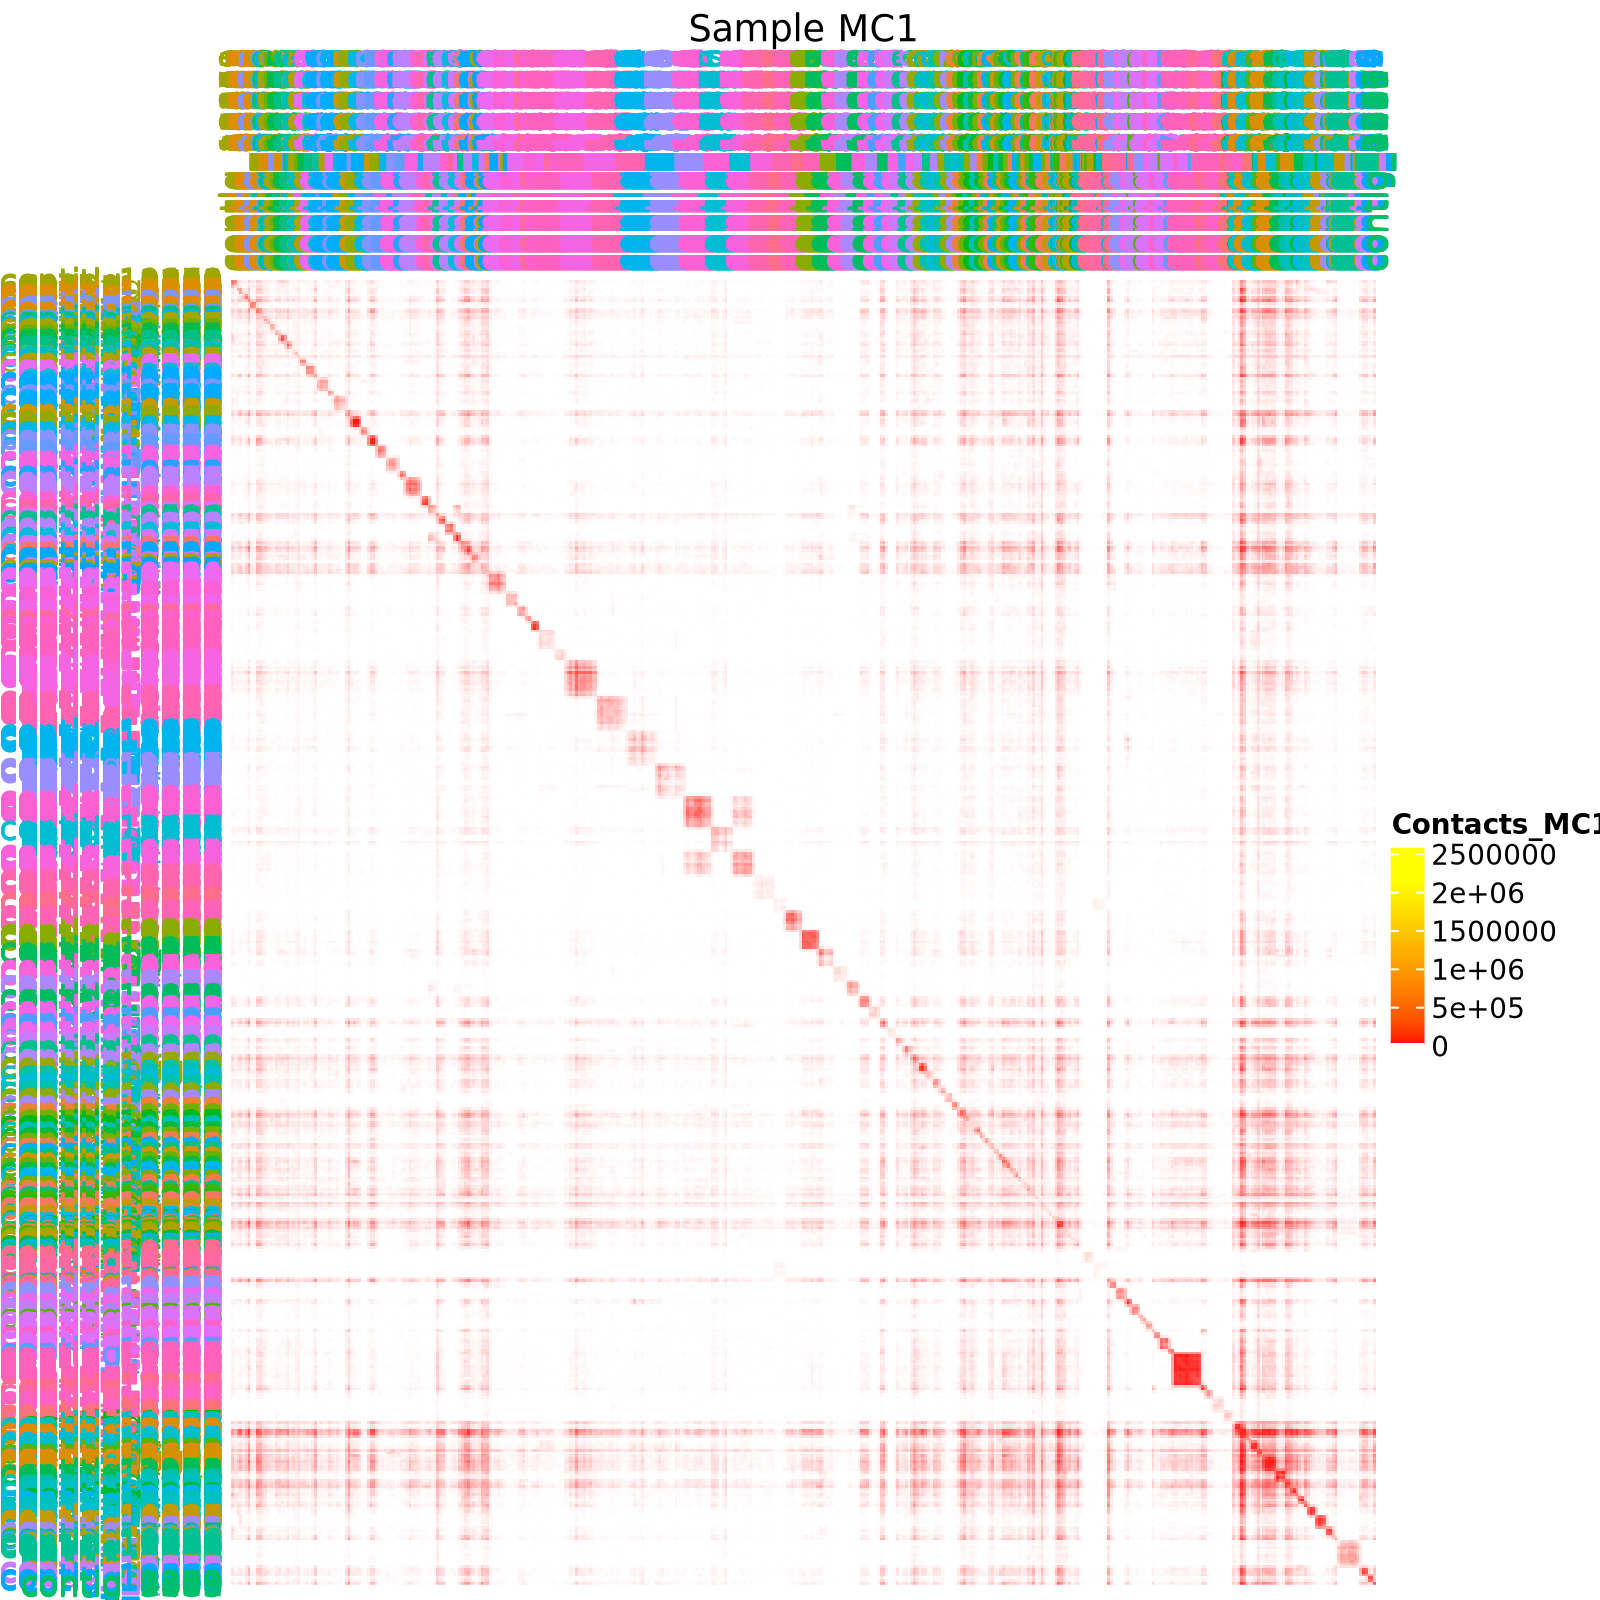

In [62]:
 p.dims(8,8)
# Heatmap of the Hi-C contacts
for (s in samples) {
  message("Plotting sample: ", s)
  mat <- make_heatmap_matrix(heatmaps[[s]], orders[[s]])
  min_nonzero <- get_min_nonzero(mat)
  
  # Get contig-to-bin mapping for this sample
  contigs <- orders[[s]]
  contig_bins <- bins %>%
    filter(contig %in% contigs)

  # Assign a color to each bin
  bin_colors <- setNames(
    scales::hue_pal()(length(unique(contig_bins$bin))),
    unique(contig_bins$bin)
  )

  # Create a named vector: contig -> color (by its bin)
  contig_colors <- setNames(
    bin_colors[contig_bins$bin],
    contig_bins$contig
  )

  # Filter to only contigs in the matrix (just to be safe)
  contig_colors <- contig_colors[intersect(names(contig_colors), rownames(mat))]

  # Build the heatmap
  ht <- Heatmap(
    mat,
    name = paste0("Contacts_", s),
    col = colorRamp2(
      c(0, get_min_nonzero(mat), max(mat)),
      c("white", "red", "yellow")
    ),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_side = "left",
    column_names_side = "top",
    column_title = paste("Sample", s),
    row_names_gp = gpar(col = contig_colors[rownames(mat)]),
    column_names_gp = gpar(col = contig_colors[colnames(mat)])
  )

  grid.newpage()
  draw(ht)
}

Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 9984738 rows containing non-finite outside the scale range
(`stat_bin()`).”


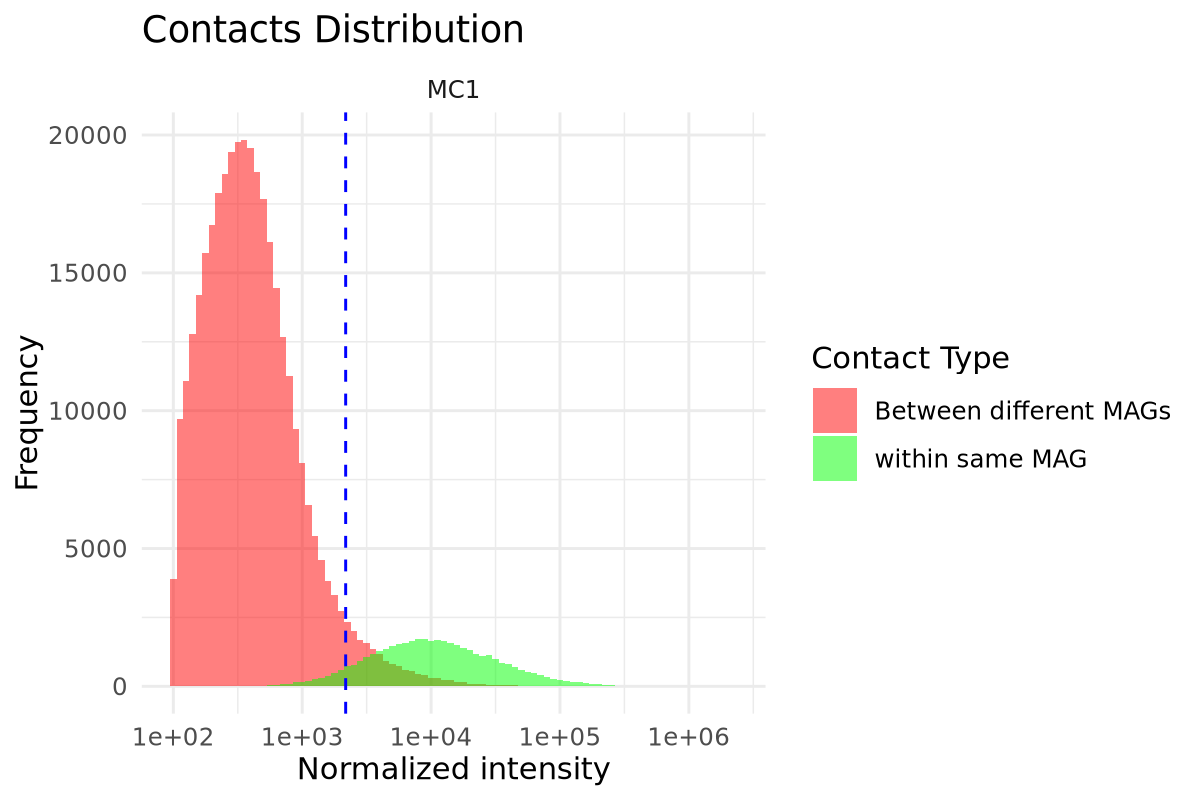

In [63]:
# Combine intra and inter contacts into a single data frame
combined_contacts <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))

# Create a data frame of thresholds
threshold_df <- data.frame(sample = names(threshold_list), threshold = unlist(threshold_list))

p.dims(6, 4)

# Plot combined histogram representing distribution of intensities for intra and inter species contacts changing x axis to logarithmic scale
ggplot(combined_contacts, aes(x = contacts, fill = Contact_Type)) +
  geom_histogram(binwidth = 0.05, alpha = 0.5, position = "identity") + 
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  scale_x_continuous(trans = 'log10') +
  facet_wrap(~ sample, scales = "free") +
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  #xlim(-1, 20) +
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold), color = "blue", linetype = "dashed") +
  theme_minimal() 

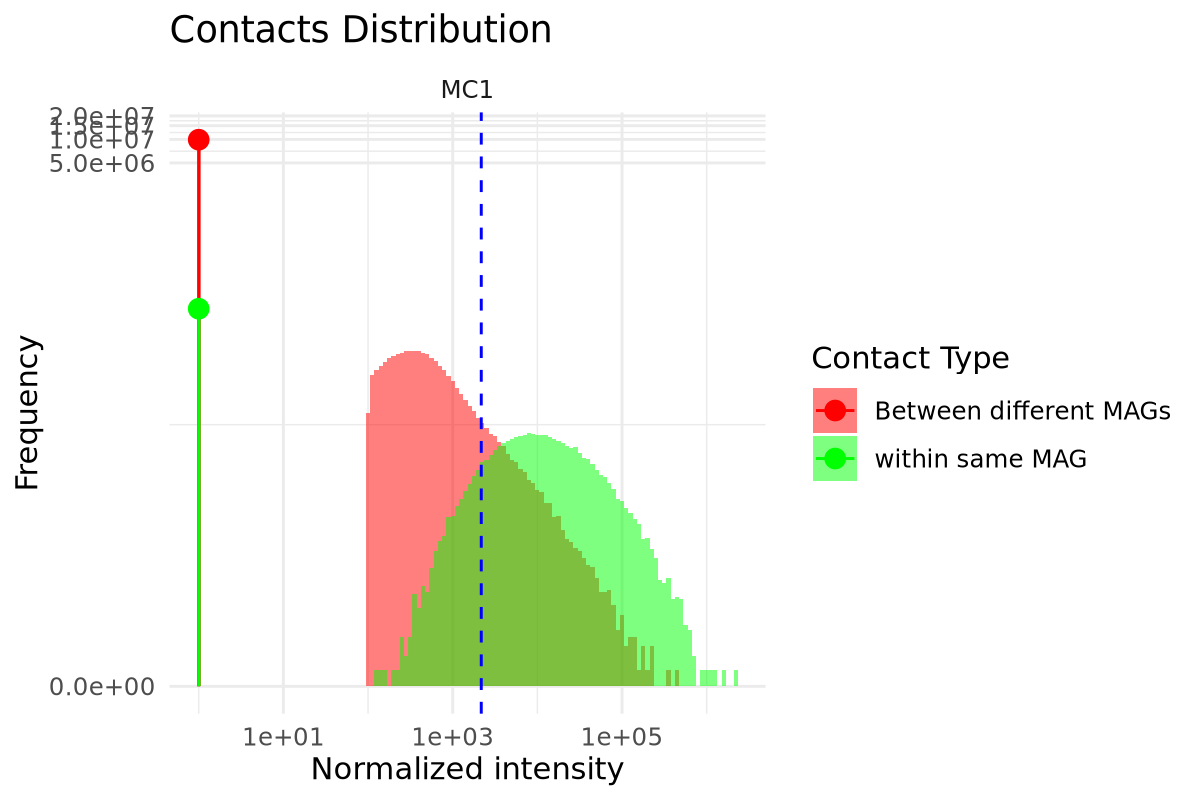

In [64]:
lollipop_data <- combined_contacts %>%
  mutate(contacts_shifted = contacts + 1,
         binned_contacts = floor(contacts_shifted / 0.1) * 0.1) %>%  # Apply binning
  group_by(Contact_Type, binned_contacts) %>%
  summarise(freq = n(), .groups = "drop")  # Count occurrences
# Separate data
zero_freq_data <- lollipop_data %>% filter(binned_contacts == 1)
#nonzero_freq_data <- lollipop_data %>% filter(binned_contacts > 1)

ggplot() +
  # Histogram for non-zero values
  geom_histogram(data = combined_contacts, aes(x = contacts + 1, fill = Contact_Type),
                 binwidth = 0.05, alpha = 0.5, position = "identity") +
  # Lollipop-style representation for zero values
  geom_segment(data = zero_freq_data, aes(x = binned_contacts, xend = binned_contacts, 
                                          y = 0, yend = freq, color = Contact_Type), linewidth = 0.5) +
  geom_point(data = zero_freq_data, aes(x = binned_contacts, y = freq, color = Contact_Type), size = 3) +
  # Axes and labels
  scale_x_continuous(trans = "log10") +
  scale_y_continuous(trans = pseudo_log_trans(base = 10)) +
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  # Facet by sample
  facet_wrap(~ sample, scales = "free") +
  # Colors
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  scale_color_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                     name = "Contact Type") +
  # Threshold line
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold + 1), color = "blue", linetype = "dashed") +
  theme_minimal()

# High quality bins only

In [65]:
# Load list with all the contacts between contigs (normalized intensities)
all_contacts <- fread(file.path(work_dir, "MC1_long_plasmids/norm/Normalized_all_contacts_list.tsv"), sep = "\t")
#all_contacts <- fread(file.path(work_dir, "MC1_long_plasmids/norm/Normalized_contacts_filtered_list.tsv"), sep = "\t")
colnames(all_contacts) <- c("index1","index2","contacts")
all_contacts

index1,index2,contacts
<chr>,<chr>,<dbl>
contig_1,contig_1000,355.456
contig_1,contig_10000,0.000
contig_1,contig_10002,0.000
contig_1,contig_10003,0.000
contig_1,contig_10005,0.000
⋮,⋮,⋮
contig_circular_4,contig_circular_7,0
contig_circular_4,contig_circular_8,0
contig_circular_6,contig_circular_7,0


In [66]:
# Filter low quality bins
bins_quality_filtered <- bins_quality %>%
    filter(Completeness >= 90 & Contamination <= 5) 
bins_quality_filtered

Name,Completeness,Contamination,Completeness_Model_Used,Translation_Table_Used,Coding_Density,Contig_N50,Average_Gene_Length,Genome_Size,GC_Content,Total_Coding_Sequences,Additional_Notes,Sample,row_num
<chr>,<dbl>,<dbl>,<chr>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<chr>,<chr>,<int>
ImputeCC_bin_0032,100,0.66,Neural Network (Specific Model),11,0.882,1816059,321.0326,3477100,0.49,3191,None,MC1,1
ImputeCC_bin_0051,100,1.28,Neural Network (Specific Model),11,0.826,1925825,318.1020,3142115,0.49,2726,None,MC1,2
MetaCC_bin_0116_sub,100,0.77,Neural Network (Specific Model),11,0.876,434143,313.1441,4253005,0.46,3977,None,MC1,5
MetaCC_bin_0154,100,3.43,Neural Network (Specific Model),11,0.865,977453,308.4561,3988900,0.42,3734,None,MC1,7
MetaCC_bin_0169,100,0.82,Neural Network (Specific Model),11,0.900,581234,306.7002,3315602,0.46,3252,None,MC1,8
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
semibin2_bin_75,91.87,0.11,Neural Network (Specific Model),11,0.872,291034,308.9771,2783876,0.41,2625,None,MC1,117
semibin2_bin_77,91.78,0.85,Gradient Boost (General Model),11,0.861,76566,303.5914,1824574,0.61,1728,None,MC1,118
ImputeCC_bin_0085,91.31,0.67,Gradient Boost (General Model),11,0.867,264067,297.3772,2463107,0.55,2399,None,MC1,120


In [67]:
bins <- bins %>%
    filter(bin %in% bins_quality_filtered$Name) 
bins

contig,bin
<chr>,<chr>
contig_13093,MetaCC_bin_0200
contig_13094,MetaCC_bin_0200
contig_1997,MetaCC_bin_0200
contig_2436,MetaCC_bin_0200
contig_2884,MetaCC_bin_0200
⋮,⋮
contig_6502,semibin2_bin_121
contig_6519,semibin2_bin_121
contig_6962,semibin2_bin_121


In [68]:
# Add bin information
contacts_bins <- contact_sym %>%
  left_join(bins, by = c("x" = "contig")) %>%
  dplyr::rename(binx = bin) %>%
  left_join(bins, by = c("y" = "contig")) %>%
  dplyr::rename(biny = bin) %>%
  filter(!is.na(binx), !is.na(biny))
contacts_bins

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
contig_1,contig_10014,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0156
contig_1,contig_1003,685.960,FALSE,FALSE,semibin2_bin_61_sub,ImputeCC_bin_0048
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9997,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77


In [69]:
# Create heatmaps and orders per sample
#samples <- unique(bins$sample)
heatmaps <- list()
orders <- list()

for (s in samples) {
  orders[[s]] <- bins %>%
#    filter(sample == s) %>%
    arrange(bin, contig) %>%
    pull(contig)

  heatmaps[[s]] <- contacts_bins %>%
#    filter(sample == s) %>%
    mutate(
      x = factor(x, levels = orders[[s]]),
      y = factor(y, levels = orders[[s]])
    )
}

heatmaps

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<fct>,<fct>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,355.456,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
contig_1,contig_10014,0.000,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0156
contig_1,contig_1003,685.960,FALSE,FALSE,semibin2_bin_61_sub,ImputeCC_bin_0048
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9997,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77


In [70]:
# Get the contig and bin association into the table with all the contacts
# Merge all_contacts with bins to get bin1
all_contacts <- merge(all_contacts, bins, by.x = c("index1"), by.y = c("contig"), all.x = TRUE)
setnames(all_contacts, "bin", "bin1")
# Merge all_contacts with bins to get bin2
all_contacts <- merge(all_contacts, bins, by.x = c("index2"), by.y = c("contig"), all.x = TRUE)
setnames(all_contacts, "bin", "bin2")
# Reorder columns to desired order
all_contacts <- all_contacts[, .(index1, index2, contacts, bin1, bin2)]
all_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10000,0.000,semibin2_bin_61_sub,NA
contig_1000,contig_10000,0.000,MetaCC_bin_0170,NA
contig_1,contig_10002,0.000,semibin2_bin_61_sub,NA
contig_1000,contig_10002,0.000,MetaCC_bin_0170,NA
⋮,⋮,⋮,⋮,⋮
contig_circular_2,contig_circular_8,10263.1,NA,NA
contig_circular_3,contig_circular_8,0.0,NA,NA
contig_circular_4,contig_circular_8,0.0,NA,NA


In [71]:
# Generate tables that contain contacts between the same MAG and different MAGs
all_contacts_no_NA <- all_contacts[!(is.na(all_contacts$bin1)|is.na(all_contacts$bin2)),]
intra_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 == all_contacts_no_NA$bin2,]
inter_contacts <- all_contacts_no_NA[all_contacts_no_NA$bin1 != all_contacts_no_NA$bin2,]
intra_contacts
inter_contacts

index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_10130,contig_10140,0.000,ImputeCC_bin_0149,ImputeCC_bin_0149
contig_10035,contig_10141,257213.423,ImputeCC_bin_0023,ImputeCC_bin_0023
contig_10036,contig_10142,74332.439,ImputeCC_bin_0111,ImputeCC_bin_0111
contig_1003,contig_10160,1343.704,ImputeCC_bin_0048,ImputeCC_bin_0048
contig_10014,contig_10201,0.000,MetaCC_bin_0156,MetaCC_bin_0156
⋮,⋮,⋮,⋮,⋮
contig_3483,contig_circular_7,0.000,MetaCC_bin_0162,MetaCC_bin_0162
contig_7516,contig_circular_7,7237.181,MetaCC_bin_0162,MetaCC_bin_0162
contig_796,contig_circular_7,0.000,MetaCC_bin_0162,MetaCC_bin_0162


index1,index2,contacts,bin1,bin2
<chr>,<chr>,<dbl>,<chr>,<chr>
contig_1,contig_1000,355.456,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,241.477,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1000,contig_10009,0.000,MetaCC_bin_0170,MetaCC_bin_0139
contig_1,contig_10011,0.000,semibin2_bin_61_sub,MetaCC_bin_0047
contig_1000,contig_10011,0.000,MetaCC_bin_0170,MetaCC_bin_0047
⋮,⋮,⋮,⋮,⋮
contig_9994,contig_circular_7,0,semibin2_bin_77,MetaCC_bin_0162
contig_9996,contig_circular_7,0,ImputeCC_bin_0022_sub,MetaCC_bin_0162
contig_9997,contig_circular_7,0,ImputeCC_bin_0022_sub,MetaCC_bin_0162


In [72]:
# Calculation of PR curves
# Convert Contact_Type to binary labels
combined_contacts_roc <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))
combined_contacts_roc$Contact_Label <- ifelse(combined_contacts_roc$Contact_Type == "within same MAG", 1, 0)

pr_list <- list()
threshold_list <- list()
auc_table <- data.frame(row.names = c("AUC Integral", "Random AUC"))

for (s in samples) {
  # Subset data by sample
  #sample_data <- subset(combined_contacts_roc, sample == s)
  sample_data <- combined_contacts_roc 
  # Calculate the Precision-Recall curve
  pr_obj <- pr.curve(scores.class0 = sample_data$contacts, weights.class0 = sample_data$Contact_Label, curve = TRUE , 
  rand.compute = TRUE,  max.compute = TRUE, min.compute = TRUE)
  print(pr_obj)
  
  # Store the PR curve object
  pr_list[[s]] <- pr_obj
  
  # Extract precision, recall, and thresholds
  recalls <- pr_obj$curve[, 1]
  precisions <- pr_obj$curve[, 2]
  thresholds <- pr_obj$curve[, 3]
  
  # Calculate F1-score for each threshold
  f1_scores <- 2 * (precisions * recalls) / (precisions + recalls)

  optimal_index <- which.max(f1_scores)
  optimal_threshold <- median(thresholds[optimal_index])
  threshold_list[[s]] <- optimal_threshold
  
  # Add AUC integral and random AUC as a new column to the table
  auc_table[[s]] <- c(pr_obj$auc.integral, pr_obj$rand[2])

  # Print the optimal threshold and corresponding F1 score
  cat("\nOptimal Threshold for sample", s, ":", optimal_threshold, "\n")
  cat("F1 Score at Optimal Threshold:", f1_scores[optimal_index], "\n")
  cat("Recall at Optimal Threshold:", recalls[optimal_index], "\n")
  cat("Precision at Optimal Threshold:", precisions[optimal_index], "\n")

}


  Precision-recall curve

    Area under curve (Integral):
     0.5334433 

    Relative area under curve (Integral):
     0.5299272 

    Area under curve (Davis & Goadrich):
     0.5334433 

    Relative area under curves (Davis & Goadrich):
     0.5299272 

    Curve for scores from  0  to  2148172 
    ( can be plotted with plot(x) )



    Maximum AUC:
     1   1 


    Minimum AUC:
     0.007479874   0.007479874 


    AUC of a random classifier:
     0.01488534   0.01488534 

Optimal Threshold for sample MC1 : 3168.626 
F1 Score at Optimal Threshold: 0.6220994 
Recall at Optimal Threshold: 0.5067789 
Precision at Optimal Threshold: 0.8053648 


In [73]:
threshold_list
auc_table

$MC1
[1] 3168.626

,MC1
,<named list>
AUC Integral,0.533443....
Random AUC,0.014885....


In [74]:
for (sample in names(auc_table)) {
  auc_integral <- as.numeric(auc_table[[sample]][1])
  random_auc   <- as.numeric(auc_table[[sample]][2])

  print(paste("The ratio for sample", sample, "is:", auc_integral/random_auc))
}

[1] "The ratio for sample MC1 is: 35.8368326387502"


Plotting sample: MC1



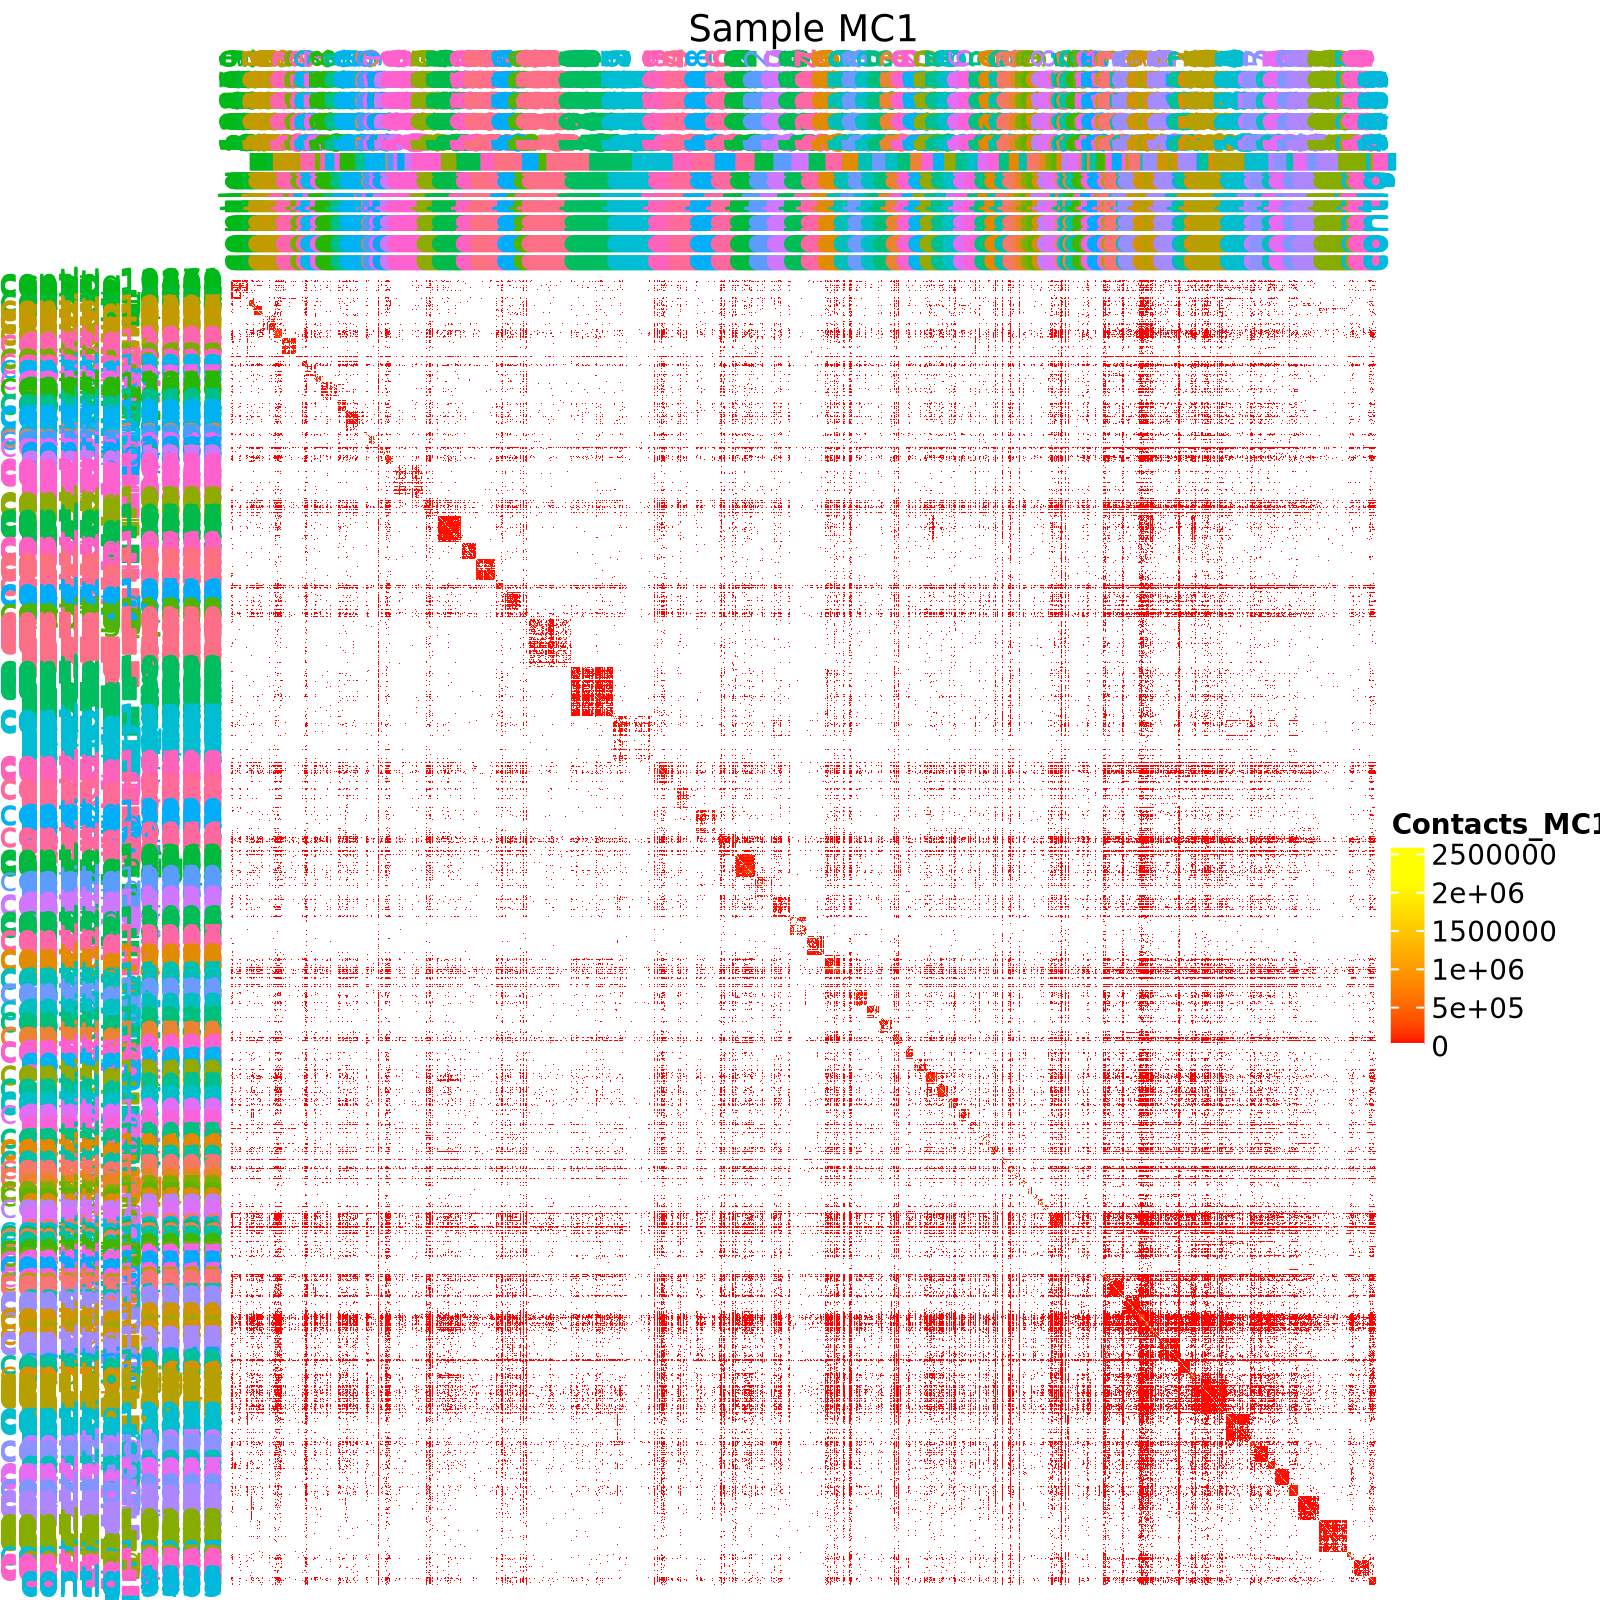

In [75]:
p.dims(8,8)
# Heatmap of the Hi-C contacts
for (s in samples) {
  message("Plotting sample: ", s)
  mat <- make_heatmap_matrix(heatmaps[[s]], orders[[s]])
  min_nonzero <- get_min_nonzero(mat)
  
  # Get contig-to-bin mapping for this sample
  contigs <- orders[[s]]
  contig_bins <- bins %>%
    filter(contig %in% contigs)

  # Assign a color to each bin
  bin_colors <- setNames(
    scales::hue_pal()(length(unique(contig_bins$bin))),
    unique(contig_bins$bin)
  )

  # Create a named vector: contig -> color (by its bin)
  contig_colors <- setNames(
    bin_colors[contig_bins$bin],
    contig_bins$contig
  )

  # Filter to only contigs in the matrix (just to be safe)
  contig_colors <- contig_colors[intersect(names(contig_colors), rownames(mat))]

  # Build the heatmap
  ht <- Heatmap(
    mat,
    name = paste0("Contacts_", s),
    col = colorRamp2(
      c(0, get_min_nonzero(mat), max(mat)),
      c("white", "red", "yellow")
    ),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_side = "left",
    column_names_side = "top",
    column_title = paste("Sample", s),
    row_names_gp = gpar(col = contig_colors[rownames(mat)]),
    column_names_gp = gpar(col = contig_colors[colnames(mat)])
  )

  grid.newpage()
  draw(ht)
}

In [76]:
heatmaps_below_threshold <- list()
for (s in samples) {
  heatmaps_below_threshold[[s]] <- copy(heatmaps[[s]])   # important: avoid modifying original
  
  thr <- threshold_list[[s]]
  
  # threshold only the numeric column (replace 'contacts' with your column name if needed)
  #heatmaps_below_threshold[[s]][contacts < 208, contacts := 0]
  heatmaps_below_threshold[[s]][contacts < thr, contacts := 0]
}
heatmaps_below_threshold

x,y,contacts,index1_in_plasmids,index2_in_plasmids,binx,biny
<fct>,<fct>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_1,contig_1000,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0170
contig_1,contig_10009,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0139
contig_1,contig_10011,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0047
contig_1,contig_10014,0,FALSE,FALSE,semibin2_bin_61_sub,MetaCC_bin_0156
contig_1,contig_1003,0,FALSE,FALSE,semibin2_bin_61_sub,ImputeCC_bin_0048
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9996,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9997,contig_9993,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,ImputeCC_bin_0111
contig_9996,contig_9994,0.00,FALSE,FALSE,ImputeCC_bin_0022_sub,semibin2_bin_77


Plotting sample: MC1



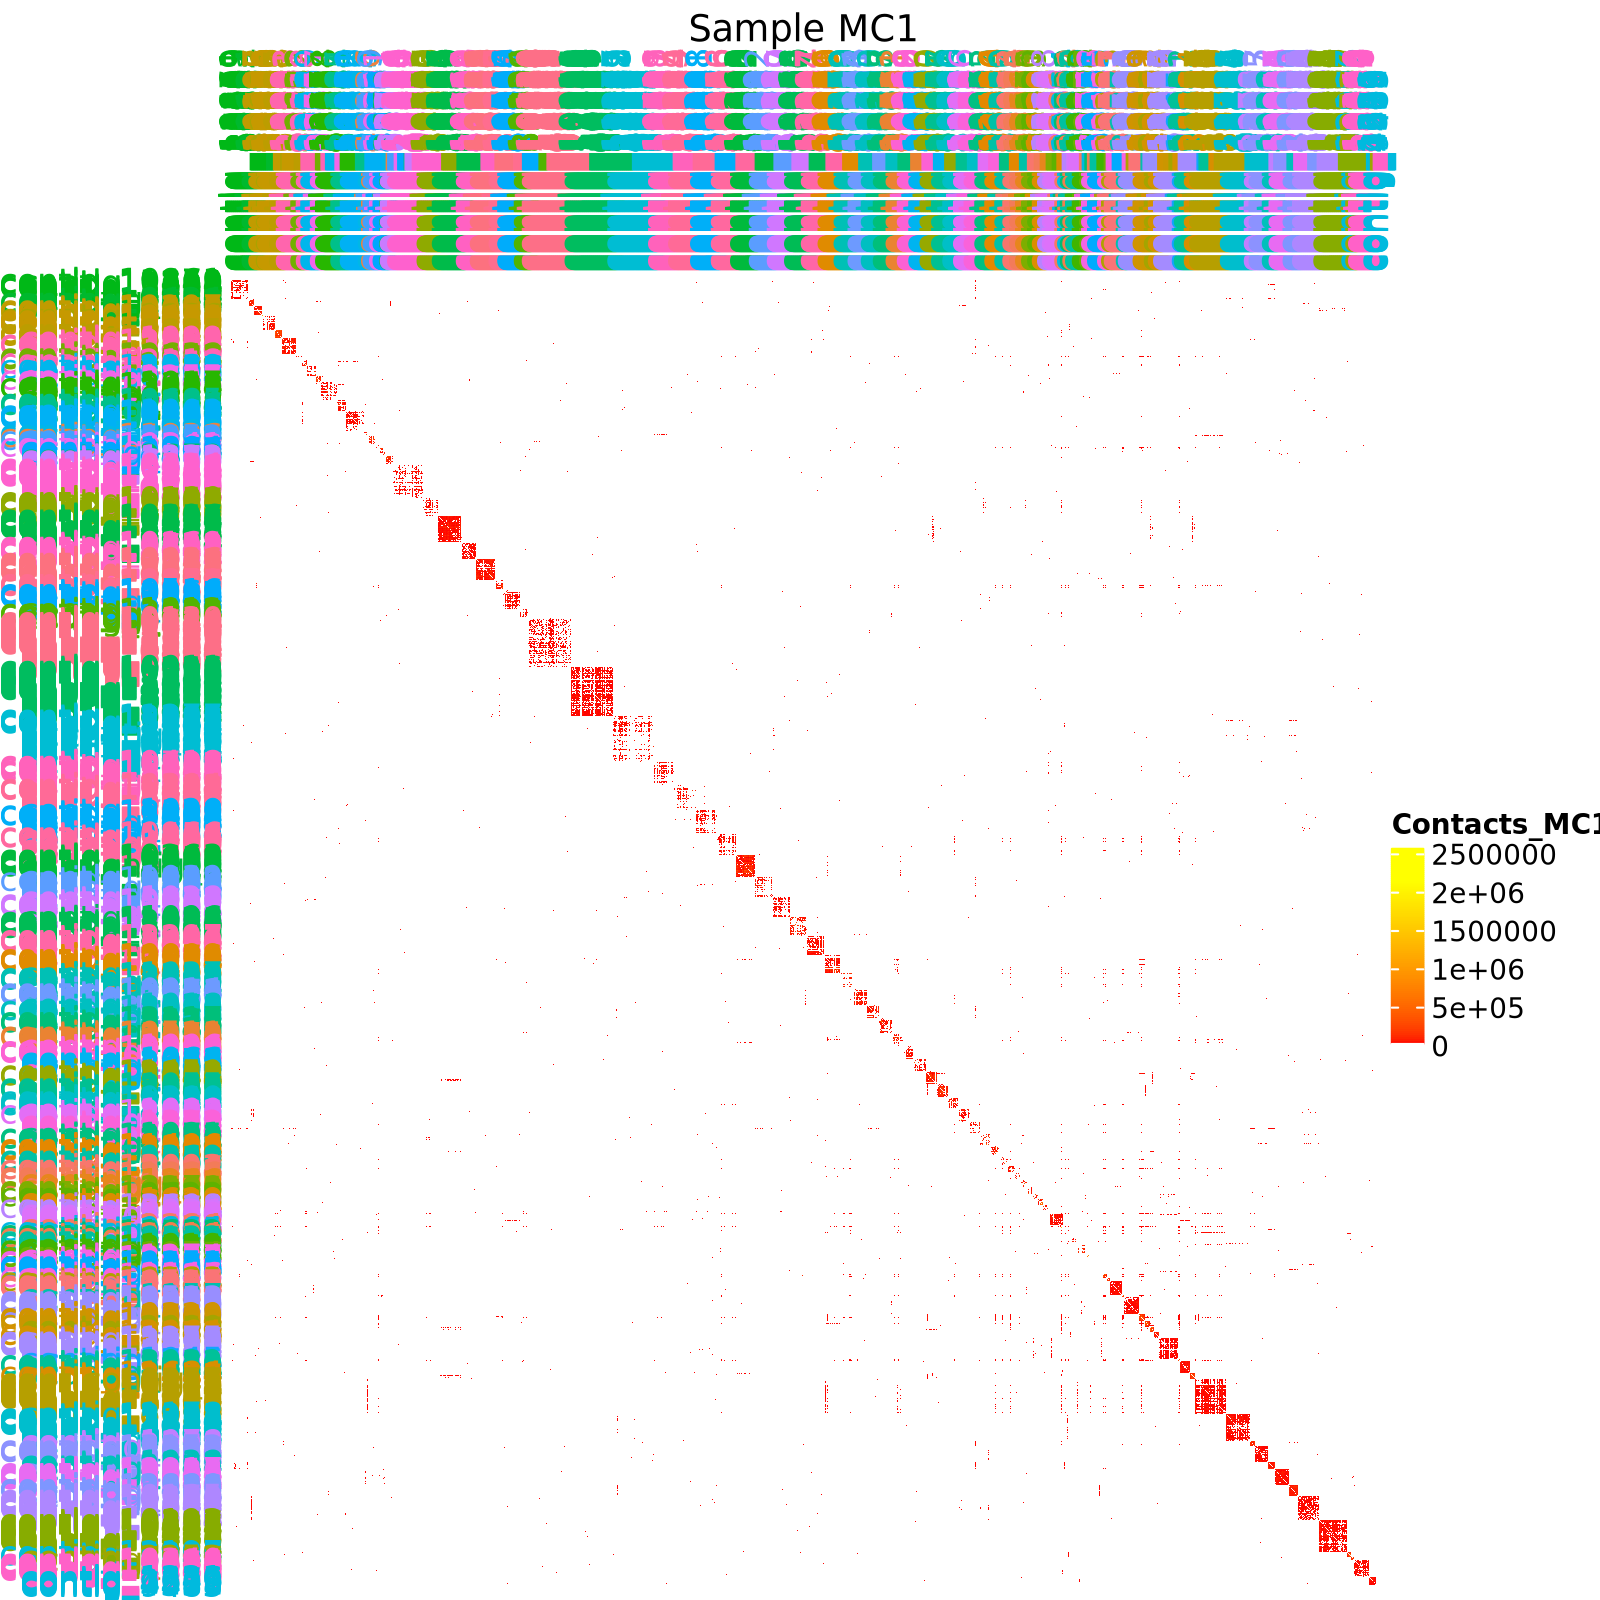

In [77]:
p.dims(8,8)
for (s in samples) {
  message("Plotting sample: ", s)
  mat <- make_heatmap_matrix(heatmaps_below_threshold[[s]], orders[[s]])
  min_nonzero <- get_min_nonzero(mat)
  
  # Get contig-to-bin mapping for this sample
  contigs <- orders[[s]]
  contig_bins <- bins %>%
    filter(contig %in% contigs)

  # Assign a color to each bin
  bin_colors <- setNames(
    scales::hue_pal()(length(unique(contig_bins$bin))),
    unique(contig_bins$bin)
  )

  # Create a named vector: contig -> color (by its bin)
  contig_colors <- setNames(
    bin_colors[contig_bins$bin],
    contig_bins$contig
  )

  # Filter to only contigs in the matrix (just to be safe)
  contig_colors <- contig_colors[intersect(names(contig_colors), rownames(mat))]

  # Build the heatmap
  ht <- Heatmap(
    mat,
    name = paste0("Contacts_", s),
    col = colorRamp2(
      c(0, get_min_nonzero(mat), max(mat)),
      c("white", "red", "yellow")
    ),
    cluster_rows = FALSE,
    cluster_columns = FALSE,
    row_names_side = "left",
    column_names_side = "top",
    column_title = paste("Sample", s),
    row_names_gp = gpar(col = contig_colors[rownames(mat)]),
    column_names_gp = gpar(col = contig_colors[colnames(mat)])
  )

  grid.newpage()
  draw(ht)
}

Warning message in scale_x_continuous(trans = "log10"):
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 1334716 rows containing non-finite outside the scale range
(`stat_bin()`).”


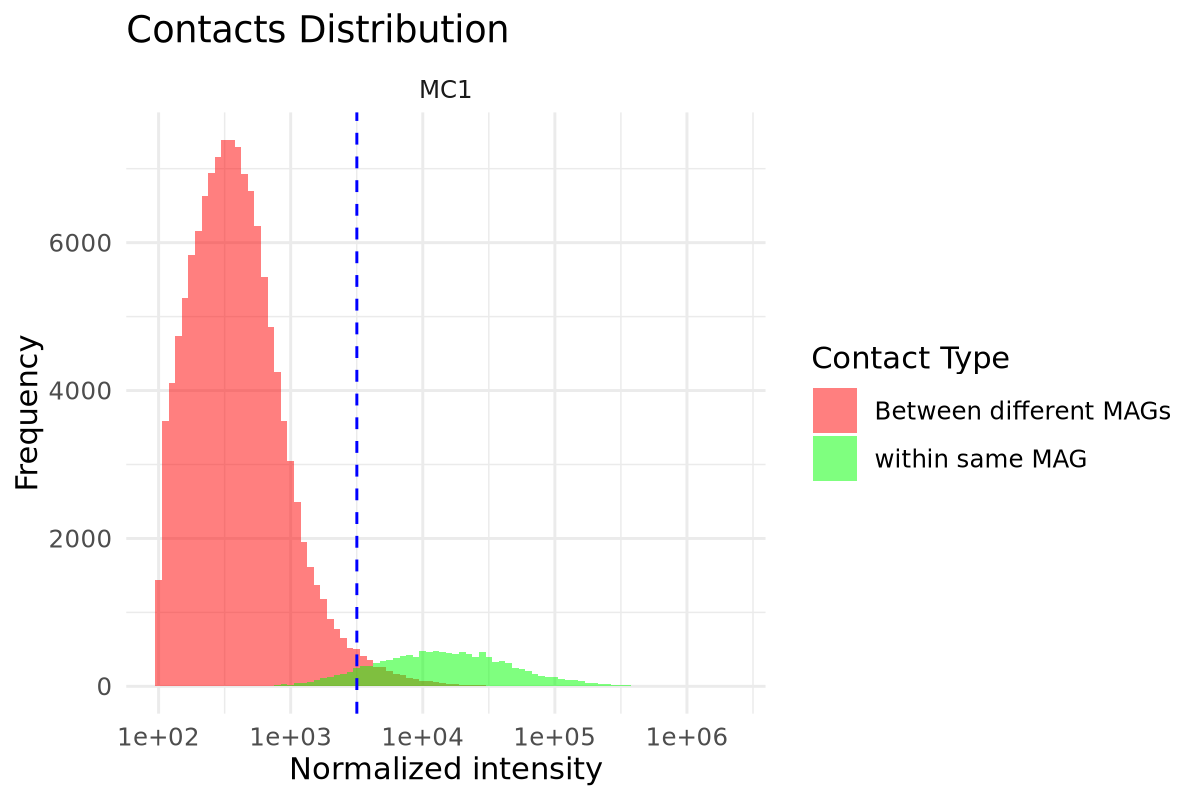

In [78]:
# Combine intra and inter contacts into a single data frame
combined_contacts <- bind_rows(mutate(intra_contacts, Contact_Type = "within same MAG"),
                               mutate(inter_contacts, Contact_Type = "Between different MAGs"))

# Create a data frame of thresholds
threshold_df <- data.frame(sample = names(threshold_list), threshold = unlist(threshold_list))

p.dims(6, 4)

# Plot combined histogram representing distribution of intensities for intra and inter species contacts changing x axis to logarithmic scale
ggplot(combined_contacts, aes(x = contacts, fill = Contact_Type)) +
  geom_histogram(binwidth = 0.05, alpha = 0.5, position = "identity") + 
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  scale_x_continuous(trans = 'log10') +
  facet_wrap(~ sample, scales = "free") +
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  #xlim(-1, 20) +
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold), color = "blue", linetype = "dashed") +
  theme_minimal() 

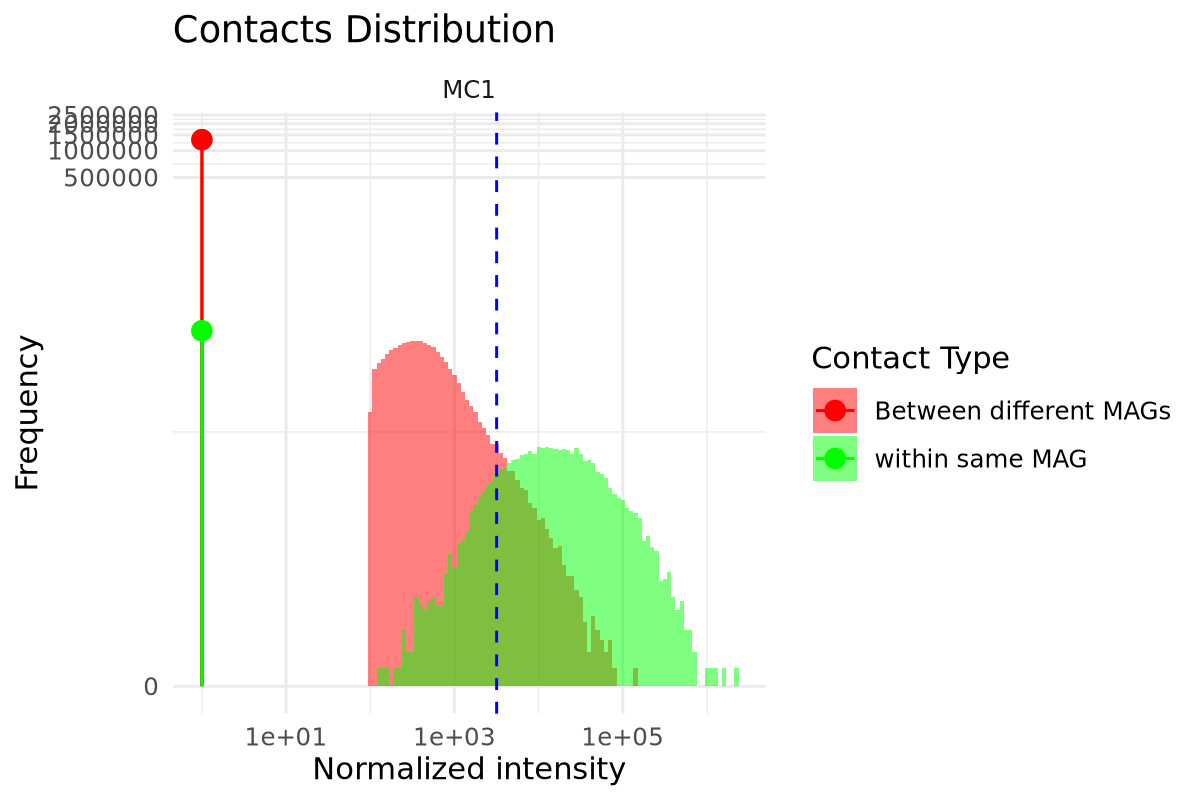

In [79]:
lollipop_data <- combined_contacts %>%
  mutate(contacts_shifted = contacts + 1,
         binned_contacts = floor(contacts_shifted / 0.1) * 0.1) %>%  # Apply binning
  group_by(Contact_Type, binned_contacts) %>%
  summarise(freq = n(), .groups = "drop")  # Count occurrences
# Separate data
zero_freq_data <- lollipop_data %>% filter(binned_contacts == 1)
#nonzero_freq_data <- lollipop_data %>% filter(binned_contacts > 1)

ggplot() +
  # Histogram for non-zero values
  geom_histogram(data = combined_contacts, aes(x = contacts + 1, fill = Contact_Type),
                 binwidth = 0.05, alpha = 0.5, position = "identity") +
  # Lollipop-style representation for zero values
  geom_segment(data = zero_freq_data, aes(x = binned_contacts, xend = binned_contacts, 
                                          y = 0, yend = freq, color = Contact_Type), linewidth = 0.5) +
  geom_point(data = zero_freq_data, aes(x = binned_contacts, y = freq, color = Contact_Type), size = 3) +
  # Axes and labels
  scale_x_continuous(trans = "log10") +
  scale_y_continuous(trans = pseudo_log_trans(base = 10)) +
  labs(title = "Contacts Distribution",
       x = "Normalized intensity",
       y = "Frequency") +
  # Facet by sample
  facet_wrap(~ sample, scales = "free") +
  # Colors
  scale_fill_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                    name = "Contact Type") +
  scale_color_manual(values = c("within same MAG" = "green", "Between different MAGs" = "red"),
                     name = "Contact Type") +
  # Threshold line
  #geom_vline(data = threshold_df, aes(xintercept = 208), color = "blue", linetype = "dashed") +
  geom_vline(data = threshold_df, aes(xintercept = threshold + 1), color = "blue", linetype = "dashed") +
  theme_minimal()

## Plasmids

### Circular plasmids

In [80]:
#Filter contacts below the threshold and add bin information. Also remove plasmid-plasmid contacts
circular_contacts_processed <- circular_contacts
for (i in samples){
  circular_contacts_processed[[i]] <- circular_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
  #circular_contacts_processed[[i]] <- circular_contacts[[i]] %>% filter(contacts > 208)
  bins_filtered <- bins #%>% filter(sample == i)
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index1", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin1")
  circular_contacts_processed[[i]] <- merge(circular_contacts_processed[[i]], bins_filtered, by.x = "index2", by.y = "contig", all.x = TRUE)
  setnames(circular_contacts_processed[[i]], "bin", "bin2")
  circular_contacts_processed[[i]] <- circular_contacts_processed[[i]][!(circular_contacts_processed[[i]]$index1_in_plasmids & circular_contacts_processed[[i]]$index2_in_plasmids), ]
}
circular_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_circular_0,contig_14173,5361.300,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2080,3905.977,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_2443,91127.236,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
contig_circular_0,contig_3684,3221.552,FALSE,TRUE,NA,MetaCC_bin_0161
contig_circular_0,contig_4000,78238.732,FALSE,TRUE,MetaCC_bin_0161,MetaCC_bin_0161
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_9030,6236.895,FALSE,TRUE,NA,NA
contig_circular_8,contig_9390,10859.376,FALSE,TRUE,NA,NA
contig_circular_8,contig_9553,11174.016,FALSE,TRUE,semibin2_bin_42,NA


In [81]:
for (i in samples){
    rows_to_swap <- circular_contacts_processed[[i]]$index1_in_plasmids == FALSE
    circular_contacts_processed[[i]][rows_to_swap, c("index1", "index2")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2", "index1")]
    circular_contacts_processed[[i]][rows_to_swap, c("bin1", "bin2")] <- circular_contacts_processed[[i]][rows_to_swap, c("bin2", "bin1")]
    circular_contacts_processed[[i]][rows_to_swap, c("index1_in_plasmids", "index2_in_plasmids")] <- circular_contacts_processed[[i]][rows_to_swap, c("index2_in_plasmids", "index1_in_plasmids")]
}
circular_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_14173,contig_circular_0,5361.300,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2080,contig_circular_0,3905.977,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_2443,contig_circular_0,91127.236,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
contig_3684,contig_circular_0,3221.552,TRUE,FALSE,MetaCC_bin_0161,NA
contig_4000,contig_circular_0,78238.732,TRUE,FALSE,MetaCC_bin_0161,MetaCC_bin_0161
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_9030,contig_circular_8,6236.895,TRUE,FALSE,NA,NA
contig_9390,contig_circular_8,10859.376,TRUE,FALSE,NA,NA
contig_9553,contig_circular_8,11174.016,TRUE,FALSE,NA,semibin2_bin_42


In [103]:
num_plas_contacts_cir <- list()
for (i in samples) {
  num_plas_contacts_cir[[i]] <- circular_contacts_processed[[i]] %>%
    dplyr::group_by(index1, bin2) %>%
    dplyr::summarise(n_rows = n(), .groups = "drop") %>%
    dplyr::filter(bin2 != "NA")
}
num_plas_contacts_cir$MC1

index1,bin2,n_rows
<chr>,<chr>,<int>
contig_circular_0,MetaCC_bin_0161,6
contig_circular_2,MetaCC_bin_0139,2
contig_circular_2,maxbin2_bin_037,1
contig_circular_2,maxbin2_bin_095_sub,1
contig_circular_2,semibin2_bin_61_sub,31
contig_circular_3,ImputeCC_bin_0058,1
contig_circular_3,MetaCC_bin_0170,1
contig_circular_3,semibin2_bin_69,16
contig_circular_4,semibin2_bin_54,2


In [105]:
mean(num_plas_contacts_cir$MC1$n_rows)

[1] 7

In [82]:
final_data_circular <- list()
# For every sample, substitude the bin name with the taxa name and merge all the contacts by the plasmid contig with the contigs that are in the same bin
for (i in samples){
    filtered_data_circular <- circular_contacts_processed[[i]] %>%
        filter(!is.na(bin2))
    median_data <- filtered_data_circular %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
    final_median_data_circular <- replace_bin_values(median_data, tax, i)
    final_data_circular[[i]] <- final_median_data_circular
    #write.table(final_median_data_circular , paste0("/ebio/abt3_projects2/long_reads_workflow/networks/", i, "/circular_plasmid_contacts_HQ_bins.tsv"), 
    #          row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)
}
final_data_circular

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_circular_0,Parabacteroides merdae,58761.32
contig_circular_2,Parabacteroides distasonis,11706.34
contig_circular_2,CAG-273 sp000435755,22709.51
contig_circular_2,Eubacterium_G sp000432355,10874.13
contig_circular_2,Phocaeicola vulgatus,13972.42
⋮,⋮,⋮
contig_circular_8,Parabacteroides distasonis,13206.340
contig_circular_8,Alistipes senegalensis,5014.047
contig_circular_8,CAG-273 sp000435755,7433.701


### Linear plasmids

In [83]:
#Filter contacts below the threshold and add bin information. Also remove plasmid-plasmid contacts
linear_contacts_processed <- linear_contacts
for (i in samples){
  linear_contacts_processed[[i]] <- linear_contacts[[i]] %>% filter(contacts > threshold_list[[i]])
  #linear_contacts_processed[[i]] <- linear_contacts[[i]] %>% filter(contacts > 208)
  bins_filtered <- bins
  linear_contacts_processed[[i]] <- merge(linear_contacts_processed[[i]], bins_filtered, by.x = "index1", by.y = "contig", all.x = TRUE)
  setnames(linear_contacts_processed[[i]], "bin", "bin1")
  linear_contacts_processed[[i]] <- merge(linear_contacts_processed[[i]], bins_filtered, by.x = "index2", by.y = "contig", all.x = TRUE)
  setnames(linear_contacts_processed[[i]], "bin", "bin2")
  linear_contacts_processed[[i]] <- linear_contacts_processed[[i]][!(linear_contacts_processed[[i]]$index1_in_plasmids & linear_contacts_processed[[i]]$index2_in_plasmids), ]
}
linear_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_10079,contig_10045,7566.140,TRUE,FALSE,NA,NA
contig_10080,contig_10045,6266.538,TRUE,FALSE,NA,NA
contig_1013,contig_1009,4461.467,TRUE,FALSE,NA,NA
contig_10148,contig_10120,59462.590,TRUE,FALSE,NA,NA
contig_1015,contig_1004,11206.066,FALSE,TRUE,NA,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_4752,9440.013,TRUE,FALSE,MetaCC_bin_0139,NA
contig_circular_8,contig_6416,21664.993,TRUE,FALSE,MetaCC_bin_0139,NA
contig_circular_8,contig_7386,27891.589,TRUE,FALSE,semibin2_bin_42,NA


In [84]:
for (i in samples){
    rows_to_swap <- linear_contacts_processed[[i]]$index1_in_plasmids == FALSE
    linear_contacts_processed[[i]][rows_to_swap, c("index1", "index2")] <- linear_contacts_processed[[i]][rows_to_swap, c("index2", "index1")]
    linear_contacts_processed[[i]][rows_to_swap, c("bin1", "bin2")] <- linear_contacts_processed[[i]][rows_to_swap, c("bin2", "bin1")]
    linear_contacts_processed[[i]][rows_to_swap, c("index1_in_plasmids", "index2_in_plasmids")] <- linear_contacts_processed[[i]][rows_to_swap, c("index2_in_plasmids", "index1_in_plasmids")]
}
linear_contacts_processed

index2,index1,contacts,index1_in_plasmids,index2_in_plasmids,bin1,bin2
<chr>,<chr>,<dbl>,<lgl>,<lgl>,<chr>,<chr>
contig_10079,contig_10045,7566.140,TRUE,FALSE,NA,NA
contig_10080,contig_10045,6266.538,TRUE,FALSE,NA,NA
contig_1013,contig_1009,4461.467,TRUE,FALSE,NA,NA
contig_10148,contig_10120,59462.590,TRUE,FALSE,NA,NA
contig_1004,contig_1015,11206.066,TRUE,FALSE,NA,NA
⋮,⋮,⋮,⋮,⋮,⋮,⋮
contig_circular_8,contig_4752,9440.013,TRUE,FALSE,MetaCC_bin_0139,NA
contig_circular_8,contig_6416,21664.993,TRUE,FALSE,MetaCC_bin_0139,NA
contig_circular_8,contig_7386,27891.589,TRUE,FALSE,semibin2_bin_42,NA


In [98]:
num_plas_contacts_lin <- list()
for (i in samples) {
  num_plas_contacts_lin[[i]] <- linear_contacts_processed[[i]] %>%
    dplyr::group_by(index1, bin2) %>%
    dplyr::summarise(n_rows = n(), .groups = "drop") %>%
    dplyr::filter(bin2 != "NA")
}
num_plas_contacts_lin$MC1

index1,bin2,n_rows
<chr>,<chr>,<int>
contig_1000,ImputeCC_bin_0012,1
contig_1000,MetaCC_bin_0170,7
contig_1000,semibin2_bin_77,1
contig_1001,ImputeCC_bin_0117,1
contig_1001,MetaCC_bin_0126_sub,2
contig_1001,semibin2_bin_84,1
contig_10022,MetaCC_bin_0167,1
contig_10045,MetaCC_bin_0154,1
contig_1006,MetaCC_bin_0162,1


In [106]:
mean(num_plas_contacts_lin$MC1$n_rows)

[1] 3.271692

In [ ]:
final_data_linear <- list()
# For every sample, substitude the bin name with the taxa name and merge all the contacts by the plasmid contig with the contigs that are in the same bin
for (i in samples){
    filtered_data_linear <- linear_contacts_processed[[i]] %>%
        filter(!is.na(bin2))
    median_data <- filtered_data_linear %>%
        group_by(index1, bin2) %>%
        summarize(median_contacts = median(contacts, na.rm = TRUE), .groups = 'drop')
    final_median_data_linear <- replace_bin_values(median_data, tax, i)
    final_data_linear[[i]] <- final_median_data_linear
    #write.table(final_median_data_linear , paste0("/ebio/abt3_projects2/long_reads_workflow/networks/", i, "/linear_plasmid_contacts_HQ_bins.tsv"), 
    #          row.names = FALSE, col.names = TRUE, sep = '\t', quote = FALSE)
}
final_data_linear

index1,bin2,median_contacts
<chr>,<chr>,<dbl>
contig_1000,UMGS1312 sp900550625,4639.874
contig_1000,CAG-83 sp000431575,40370.819
contig_1000,CAG-83 sp000435975,3585.404
contig_1001,CAG-83 sp000435555,5929.977
contig_1001,Fusicatenibacter saccharivorans,4480.600
⋮,⋮,⋮
contig_997,Anaeromassilibacillus sp001305115,8568.799
contig_997,Faecousia sp000434635,7555.606
contig_997,CAG-83 sp900547745,3756.982
